In [1]:
import tensorflow as tf
import keras
from keras import layers
import pickle
import numpy as np
import pandas as pd
import glob
import xarray as xr
from keras.models import load_model

from scipy.stats import norm
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy
import cartopy.crs as ccrs

import shap
import warnings
warnings.filterwarnings("ignore")
from alibi.explainers import IntegratedGradients, KernelShap
import os
import scipy as sp
import scipy.ndimage
from matplotlib.transforms import Bbox
import matplotlib.patches as patches

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
def get_gradients(inputs, top_pred_idx=None):
    """Computes the gradients of outputs w.r.t input image.

    Args:
        inputs: 2D/3D/4D matrix of samples
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.

    Returns:
        Gradients of the predictions w.r.t img_input
    """
    inputs = tf.cast(inputs, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(inputs)
        
        # Run the forward pass of the layer and record operations
        # on GradientTape.
        preds = model(inputs, training=False)  
        
        # For classification, grab the top class
        if top_pred_idx is not None:
            preds = preds[:, top_pred_idx]
        
    # Use the gradient tape to automatically retrieve
    # the gradients of the trainable variables with respect to the loss.        
    grads = tape.gradient(preds, inputs)
    
    return grads

In [3]:
def get_integrated_gradients(inputs, baseline=None, num_steps=50, top_pred_idx=None):
    """Computes Integrated Gradients for a prediction.

    Args:
        inputs (ndarray): 2D/3D/4D matrix of samples
        baseline (ndarray): The baseline image to start with for interpolation
        num_steps: Number of interpolation steps between the baseline
            and the input used in the computation of integrated gradients. These
            steps along determine the integral approximation error. By default,
            num_steps is set to 50.
        top_pred_idx: (optional) Predicted label for the x_data
                      if classification problem. If regression,
                      do not include.            

    Returns:
        Integrated gradients w.r.t input image
    """
    # If baseline is not provided, start with zeros
    # having same size as the input image.
    if baseline is None:
        input_size = np.shape(inputs)[1:]
        baseline = np.zeros(input_size).astype(np.float32)
    else:
        baseline = baseline.astype(np.float32)

    # 1. Do interpolation.
    inputs = inputs.astype(np.float32)
    interpolated_inputs = [
        baseline + (step / num_steps) * (inputs - baseline)
        for step in range(num_steps + 1)
    ]
    interpolated_inputs = np.array(interpolated_inputs).astype(np.float32)

    # 3. Get the gradients
    grads = []
    for i, x_data in enumerate(interpolated_inputs):
        grad = get_gradients(x_data, top_pred_idx=top_pred_idx)     
        grads.append(grad)
    grads = tf.convert_to_tensor(grads, dtype=tf.float32)

    # 4. Approximate the integral using the trapezoidal rule
    grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads, axis=0)
    # 5. Calculate integrated gradients and return
    integrated_grads = (inputs - baseline) * avg_grads
    
    return integrated_grads

In [4]:
lat = np.arange(-90, 90, 180/192)
lon = np.arange(0, 360, 360/288)

lat_bnd1 = np.where(lat==10.3125)[0][0]
lat_bnd2 = np.where(lat==50.625)[0][0]
lon_bnd1 = np.where(lon==210)[0][0]
lon_bnd2 = np.where(lon==300)[0][0]

In [5]:
### ERA5 Data

In [6]:
#set the base path 
base_path = '/sfs/weka/scratch/zkq5md'

#load the dataframe
df_se_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/SE_detrend_precip.csv', index_col='Unnamed: 0')
df_gp_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/GP_detrend_precip.csv', index_col='Unnamed: 0')
df_ca_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/CA_detrend_precip.csv', index_col='Unnamed: 0')
df_se_era5

,Datetimes,Maximum Precipitation,lats,lons
0,1950-01-01,29.729749,32.8125,266.25
1,1950-01-02,39.121912,35.6250,270.00
2,1950-01-03,18.399313,35.6250,266.25
3,1950-01-04,59.563390,35.6250,267.50
4,1950-01-05,40.699897,35.6250,271.25
...,...,...,...,...
9977,2015-12-27,75.272000,34.6875,266.25
9978,2015-12-28,51.817838,35.6250,267.50
9979,2015-12-29,26.021470,34.6875,276.25
9980,2015-12-30,44.338429,30.9375,271.25


In [7]:
with open(f'{base_path}/Data/ERA5/Final/X_era5.pkl', "rb") as f:
    x = pickle.load(f)
    
x = np.transpose(np.array(x), (0, 2, 3, 1))

x = x[:, lat_bnd1:lat_bnd2, lon_bnd1:lon_bnd2, :]

x_test_era5 = x[8000:]

y_se_era5_test = df_se_era5.iloc[8000:]
y_gp_era5_test = df_gp_era5.iloc[8000:]
y_ca_era5_test = df_ca_era5.iloc[8000:]

y_se_era5_test = y_se_era5_test.reset_index()
y_se_era5_test = y_se_era5_test.sample(n=200, random_state=42)

y_gp_era5_test = y_gp_era5_test.reset_index()
y_gp_era5_test = y_gp_era5_test.sample(n=200, random_state=42)

y_ca_era5_test = y_ca_era5_test.reset_index()
y_ca_era5_test = y_ca_era5_test.sample(n=200, random_state=42)

In [8]:
lat_bnd1_se = np.where(lat[lat_bnd1:lat_bnd2]==28.125)[0][0]
lat_bnd2_se = np.where(lat[lat_bnd1:lat_bnd2]==36.5625)[0][0]
lon_bnd1_se = np.where(lon[lon_bnd1:lon_bnd2]==266.25)[0][0]
lon_bnd2_se = np.where(lon[lon_bnd1:lon_bnd2]==280)[0][0]

lat_bnd1_gp = np.where(lat[lat_bnd1:lat_bnd2]==27.1875)[0][0]
lat_bnd2_gp = np.where(lat[lat_bnd1:lat_bnd2]==44.0625)[0][0]
lon_bnd1_gp = np.where(lon[lon_bnd1:lon_bnd2]==252.5)[0][0]
lon_bnd2_gp = np.where(lon[lon_bnd1:lon_bnd2]==263.75)[0][0]

lat_bnd1_ca = np.where(lat[lat_bnd1:lat_bnd2]==30.9375)[0][0]
lat_bnd2_ca = np.where(lat[lat_bnd1:lat_bnd2]==44.0625)[0][0]
lon_bnd1_ca = np.where(lon[lon_bnd1:lon_bnd2]==235)[0][0]
lon_bnd2_ca = np.where(lon[lon_bnd1:lon_bnd2]==246.25)[0][0]

In [14]:
locs = ['gp', 'se', 'ca']
model_types = ['mse', 'weight_mse', 'weight_mae']

for loc in locs:
    
    lat_bnd1 = locals()[f'lat_bnd1_{loc}']
    lat_bnd2 = locals()[f'lat_bnd2_{loc}']
    lon_bnd1 = locals()[f'lon_bnd1_{loc}']
    lon_bnd2 = locals()[f'lon_bnd2_{loc}']
    
    for model_type in model_types:
        locals()[f'{model_type}_avg_{loc}'] = []
        locals()[f'{model_type}_std_{loc}'] = []
        locals()[f'{model_type}_{loc}_pred_error'] = np.zeros((200,10))
        locals()[f'{loc}_cwv_max'] = []
        locals()[f'{loc}_cwv_area'] = []
        locals()[f'{model_type}_itg_{loc}_cwv'] = []
        locals()[f'{model_type}_itg_{loc}_z500'] = []
        locals()[f'{model_type}_itg_{loc}_tas'] = []
        

        for sample_id, sample in enumerate(locals()[f'y_{loc}_era5_test'].index.values):

            model_list = glob.glob(f'{base_path}/Data/ERA5/models/trans_learn/pre/{loc}_max_precip_{model_type}_model*')

            itgs = []

            for model_path in model_list:

                model_num = model_path.split('/')[-1].split('_')[-1].split('.')[0]

                if model_type == 'weight_mse':
                    model = load_model(f"{model_path}", compile=False)

                else:
                    model = load_model(f"{model_path}", safe_mode=False)

                itgs.append(get_integrated_gradients(np.expand_dims(x_test_era5[sample], 0)).numpy().flatten())
                pred_error = (np.abs(model.predict(np.expand_dims(x_test_era5[sample], 0), verbose=0)[0][0] -
                               locals()[f'y_{loc}_era5_test'].iloc[sample_id]['Maximum Precipitation'])/
                            locals()[f'y_{loc}_era5_test'].iloc[sample_id]['Maximum Precipitation'])*100

                locals()[f'{model_type}_{loc}_pred_error'][sample_id, int(model_num)-1] = pred_error

            igs_flat = np.array(itgs)
            corr_matrix = np.corrcoef(igs_flat)
            corr_matrix = np.unique(corr_matrix.flatten())
            locals()[f'{model_type}_avg_{loc}'].append(np.mean(corr_matrix[corr_matrix <= 0.99]))
            locals()[f'{model_type}_std_{loc}'].append(np.std(corr_matrix[corr_matrix <= 0.99]))
            
            locals()[f'{model_type}_itg_{loc}_cwv'].append(np.sum(np.abs(np.mean(np.array(itgs), axis=0)[:3096])))
            locals()[f'{model_type}_itg_{loc}_z500'].append(np.sum(np.abs(np.mean(np.array(itgs), axis=0)[3096:3096*2])))
            locals()[f'{model_type}_itg_{loc}_tas'].append(np.sum(np.abs(np.mean(np.array(itgs), axis=0)[3096*2:])))

            #print(f'Current loss fucntion: {model_type} - {str(sample_id/200*100)[:4]}% ', end="\r", flush=True)

            locals()[f'{loc}_cwv_max'].append(np.max(x_test_era5[sample,lat_bnd1:lat_bnd2, lon_bnd1:lon_bnd2,0]))
            locals()[f'{loc}_cwv_area'].append(np.sum(x_test_era5[sample,lat_bnd1:lat_bnd2, lon_bnd1:lon_bnd2,0] > 0))
            
        locals()[f'y_{loc}_era5_test'][f'{model_type}_corr'] = locals()[f'{model_type}_avg_{loc}']
        locals()[f'y_{loc}_era5_test'][f'{model_type}_std'] = locals()[f'{model_type}_std_{loc}']
        locals()[f'y_{loc}_era5_test'][f'{model_type}_error'] = np.mean(locals()[f'{model_type}_{loc}_pred_error'], axis=1)
        
        locals()[f'y_{loc}_era5_test'][f'{model_type}_itg_cwv'] = locals()[f'{model_type}_itg_{loc}_cwv']
        locals()[f'y_{loc}_era5_test'][f'{model_type}_itg_z500'] = locals()[f'{model_type}_itg_{loc}_z500']
        locals()[f'y_{loc}_era5_test'][f'{model_type}_itg_tas'] = locals()[f'{model_type}_itg_{loc}_tas']
        
    locals()[f'y_{loc}_era5_test'][f'cwv_max'] = locals()[f'{loc}_cwv_max']
    locals()[f'y_{loc}_era5_test'][f'cwv_area'] = locals()[f'{loc}_cwv_area']

I0000 00:00:1782828796.161662  993641 service.cc:146] XLA service 0x7f5f5c0084c0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782828796.161885  993641 service.cc:154]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1782828796.737579  993641 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



KeyboardInterrupt



In [13]:
np.mean(np.array(itgs), axis=0)

nan

In [15]:
locs = ['gp', 'se', 'ca']

for loc in locs:
    
    locals()[f'y_{loc}_era5_test'] = pd.read_csv(f'y_{loc}_era5_test')

FileNotFoundError: [Errno 2] No such file or directory: 'y_gp_era5_test'

In [ ]:
y_ca_era5_test

In [3]:
import requests
from io import StringIO

url = 'https://psl.noaa.gov/data/correlation/oni.data'
response = requests.get(url, verify=False)  # Disable SSL verify just for this request
data = StringIO(response.text)

column_names = ['Year', '1', '2', '3', '4', '5', '6',
                '7', '8', '9','10', '11', '12']


oni = pd.read_table(data, delim_whitespace=True, skiprows=1, names=column_names)
oni.iloc[:76]

,Year,1,2,3,4,5,6,7,8,9,10,11,12
0,1950,-1.53,-1.34,-1.16,-1.18,-1.07,-0.85,-0.54,-0.42,-0.39,-0.44,-0.60,-0.80
1,1951,-0.82,-0.54,-0.17,0.18,0.36,0.58,0.70,0.89,0.99,1.15,1.04,0.81
2,1952,0.53,0.37,0.34,0.29,0.20,0.00,-0.08,0.00,0.15,0.10,0.04,0.15
3,1953,0.40,0.60,0.63,0.66,0.75,0.77,0.75,0.73,0.78,0.84,0.84,0.81
4,1954,0.76,0.47,-0.05,-0.41,-0.54,-0.50,-0.64,-0.84,-0.90,-0.77,-0.73,-0.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,2021,-1.05,-0.93,-0.84,-0.66,-0.48,-0.38,-0.40,-0.49,-0.67,-0.81,-0.98,-0.98
72,2022,-0.97,-0.93,-0.99,-1.06,-0.99,-0.85,-0.81,-0.91,-1.01,-0.99,-0.92,-0.83
73,2023,-0.68,-0.43,-0.15,0.16,0.48,0.77,1.07,1.32,1.56,1.78,1.92,1.95
74,2024,1.78,1.48,1.14,0.71,0.39,0.15,0.04,-0.11,-0.21,-0.26,-0.37,-0.53


In [4]:
url = "http://www.bom.gov.au/climate/mjo/graphics/rmm.74toRealtime.txt"
headers = {'User-Agent': 'Mozilla/5.0'}

# Request and read
response = requests.get(url, headers=headers)
response.raise_for_status()

# Load into DataFrame
mjo = pd.read_csv(
    StringIO(response.text),
    delim_whitespace=True,
    comment='#',
    names=['month', 'day', 'RMM1', 'RMM2', 'phase', 'amplitude', 'Useless'],
    skiprows=2
)

mjo['Year'] = mjo.index.values
mjo = mjo.drop(columns = 'Useless')
mjo

,month,day,RMM1,RMM2,phase,amplitude,Year
1974,6,1,1.634470,1.203040,5,2.029480,1974
1974,6,2,1.602890,1.015120,5,1.897290,1974
1974,6,3,1.516250,1.085510,5,1.864760,1974
1974,6,4,1.509810,1.035730,5,1.830920,1974
1974,6,5,1.559060,1.305180,5,2.033260,1974
...,...,...,...,...,...,...,...
2024,2,20,-0.305918,0.305419,8,0.432281,2024
2024,2,21,0.103033,0.071931,5,0.125658,2024
2024,2,22,0.236122,0.248544,6,0.342823,2024
2024,2,23,0.201856,0.325106,6,0.382675,2024


In [5]:
for loc in locs:
    
    oni_vals = []
    mjo_vals = []
    mjo_amps = []

    for rid, row in locals()[f'y_{loc}_era5_test'].iterrows():
        oni_val = oni[(oni['Year'] == row.Datetimes[:4])][str(int(row.Datetimes[5:7]))]

        oni_vals.append(float(oni_val.values[0]))

        mjo_cur = mjo[((mjo['Year']==int(row.Datetimes[:4])) & (mjo['month']==int(row.Datetimes[5:7]))
                       & (mjo['day']==int(row.Datetimes[8:10])))]

        mjo_vals.append(mjo_cur['phase'].values[0])
        mjo_amps.append(mjo_cur['amplitude'].values[0])
        
    locals()[f'y_{loc}_era5_test']['MJO Phase'] = np.array(mjo_vals)
    locals()[f'y_{loc}_era5_test']['MJO Amp'] = np.array(mjo_amps)
    locals()[f'y_{loc}_era5_test']['NINO Value'] = np.array(oni_vals)
    

In [6]:
locals()[f'y_{loc}_era5_test'].nlargest(10, 'mse_corr')

,Unnamed: 0,index,Datetimes,Maximum Precipitation,lats,lons,mse_corr,mse_std,mse_error,mse_itg_cwv,...,weight_mae_std,weight_mae_error,weight_mae_itg_cwv,weight_mae_itg_z500,weight_mae_itg_tas,cwv_max,cwv_area,MJO Phase,MJO Amp,NINO Value
111,414,8414,2005-11-06,57.313503,41.2500,236.25,0.856135,0.041625,4.686315,84.672220,...,0.034206,7.424326,34.289883,139.59200,1235.23340,1.809870,124,5,0.853948,-0.57
25,1518,9518,2012-12-21,47.461983,40.3125,237.50,0.850560,0.057006,13.079993,49.920240,...,0.056258,16.684882,23.425564,371.49817,1437.51620,1.056353,40,2,0.774205,-0.21
172,544,8544,2006-03-16,35.990450,41.2500,236.25,0.825247,0.065007,7.674507,34.308510,...,0.063564,12.117367,18.184750,106.28029,1010.14840,0.727739,55,4,0.507370,-0.57
59,1270,9270,2011-02-14,12.595532,39.3750,236.25,0.787375,0.066979,100.515881,63.076070,...,0.102111,97.726390,37.413880,98.85842,850.62000,0.770524,43,6,0.371755,-1.19
146,1766,9766,2014-03-28,30.553463,42.1875,235.00,0.769665,0.062874,12.142763,61.358353,...,0.119770,12.434873,30.834984,170.18355,842.79250,2.533833,116,2,1.427604,-0.27
132,471,8471,2006-01-02,89.496960,36.5625,241.25,0.730349,0.116679,20.047872,99.563930,...,0.084367,10.293358,78.713550,1019.79160,909.10455,2.828311,121,8,1.270170,-0.85
117,865,8865,2008-11-03,36.804058,43.1250,235.00,0.682881,0.128998,10.325117,88.438805,...,0.149769,8.709480,40.720720,143.27524,1035.20350,1.606650,125,6,0.693829,-0.55
96,1117,9117,2010-02-12,21.282497,42.1875,236.25,0.680185,0.068254,16.919146,34.870247,...,0.177341,23.274284,17.874445,76.85120,431.58050,0.708376,88,8,2.042824,1.22
159,1313,9313,2011-03-29,13.393968,43.1250,235.00,0.622381,0.103491,96.923471,37.174232,...,0.119484,58.549815,17.692684,107.74927,728.28784,2.883074,103,5,1.239788,-0.93
98,1110,9110,2010-02-05,28.364657,33.7500,240.00,0.616491,0.146560,14.057136,105.669780,...,0.111106,13.940572,46.842056,475.85767,597.38010,1.757263,118,7,1.713101,1.22


In [7]:
y_gp_era5_test.nlargest(10, 'mse_corr')

,Unnamed: 0,index,Datetimes,Maximum Precipitation,lats,lons,mse_corr,mse_std,mse_error,mse_itg_cwv,...,weight_mae_std,weight_mae_error,weight_mae_itg_cwv,weight_mae_itg_z500,weight_mae_itg_tas,cwv_max,cwv_area,MJO Phase,MJO Amp,NINO Value
94,874,8874,2008-11-12,10.746368,27.1875,262.50,0.741055,0.082059,103.932333,50.417310,...,0.076645,63.581911,40.521996,1084.96690,88.621770,1.427866,82,4,1.359958,-0.55
9,1668,9668,2013-12-20,44.247689,27.1875,252.50,0.657887,0.097672,51.720870,106.470400,...,0.126658,57.711829,76.425410,766.10925,115.367170,2.460926,133,5,1.102984,-0.27
19,1320,9320,2011-11-05,14.709372,37.5000,252.50,0.651097,0.127740,6.195376,39.664300,...,0.134067,11.585465,15.630971,287.07394,429.836730,1.108195,72,4,1.387894,-1.09
7,777,8777,2008-01-06,23.071681,37.5000,252.50,0.644113,0.066487,14.728786,36.027023,...,0.081451,18.427453,15.815485,265.42444,419.836980,2.561847,127,6,2.142476,-1.64
76,1909,9909,2015-03-20,26.559131,30.9375,258.75,0.618397,0.061381,19.846627,124.316590,...,0.100501,12.025160,83.849556,964.26490,109.965096,3.003695,116,8,3.702015,0.53
157,275,8275,2004-11-18,33.813671,40.3125,260.00,0.609899,0.149938,17.671129,55.721150,...,0.172073,24.564062,22.632431,266.90790,946.947140,4.240885,136,4,0.105985,0.66
34,231,8231,2004-03-05,13.200363,40.3125,262.50,0.608233,0.123654,85.599246,67.901250,...,0.128900,65.442042,59.001534,538.75824,348.347300,1.789384,94,3,0.870421,0.23
129,1009,9009,2009-03-27,34.836237,37.5000,257.50,0.566542,0.162087,8.512802,67.806680,...,0.121322,13.292006,42.027740,815.49770,376.013920,0.704112,19,8,2.022593,-0.61
149,1450,9450,2012-03-14,3.970968,31.8750,262.50,0.555271,0.144384,38.125583,61.449090,...,0.151096,38.300207,18.412992,420.17667,145.511350,2.322194,87,5,1.872032,-0.59
17,1223,9223,2010-12-29,24.451898,33.7500,262.50,0.546815,0.126411,40.257669,89.137695,...,0.147693,41.339720,63.838210,623.71250,140.460940,1.298578,94,5,0.509257,-1.59


In [8]:
y_se_era5_test.nlargest(10, 'mse_corr')

,Unnamed: 0,index,Datetimes,Maximum Precipitation,lats,lons,mse_corr,mse_std,mse_error,mse_itg_cwv,...,weight_mae_std,weight_mae_error,weight_mae_itg_cwv,weight_mae_itg_z500,weight_mae_itg_tas,cwv_max,cwv_area,MJO Phase,MJO Amp,NINO Value
155,968,8968,2009-02-14,32.208062,30.0000,270.00,0.798922,0.072432,26.083312,107.824230,...,0.054286,17.678931,68.950150,653.81000,62.318840,2.664373,89,7,0.459812,-0.79
94,874,8874,2008-11-12,51.447929,30.9375,266.25,0.743324,0.058666,11.033360,80.658670,...,0.131346,18.943205,49.491497,1272.20290,138.686200,1.482264,98,4,1.359958,-0.55
137,892,8892,2008-11-30,57.637050,32.8125,277.50,0.735268,0.076255,10.759448,156.145260,...,0.066596,21.391485,123.911770,3121.26680,350.472300,2.101989,74,7,1.518701,-0.55
96,1117,9117,2010-02-12,42.678148,28.1250,270.00,0.732045,0.070054,22.571101,97.222180,...,0.052704,24.979227,101.886720,2167.18800,90.558360,0.848847,59,8,2.042824,1.22
112,1831,9831,2015-01-01,19.516212,32.8125,266.25,0.703025,0.050376,50.133527,123.009170,...,0.095496,32.272488,71.667150,833.79830,87.816270,1.365309,69,5,1.873171,0.55
172,544,8544,2006-03-16,3.747783,30.9375,268.75,0.662854,0.125778,58.255390,60.651035,...,0.114318,34.490825,45.167496,602.54407,36.323673,1.352227,38,4,0.507370,-0.57
142,1179,9179,2010-11-15,47.090455,32.8125,271.25,0.644631,0.102002,4.625395,143.436000,...,0.140025,14.895082,99.402084,2038.29090,144.831940,1.372732,62,8,1.178629,-1.64
89,1713,9713,2014-02-03,35.876982,35.6250,276.25,0.633541,0.083579,37.830666,63.392260,...,0.087597,48.959378,33.375576,681.44000,259.271420,1.792534,86,7,1.093206,-0.46
135,120,8120,2003-11-15,21.545254,35.6250,270.00,0.628163,0.122313,50.154796,85.482320,...,0.109996,47.535076,60.927307,306.82947,93.527664,1.684729,34,4,0.635866,0.35
129,1009,9009,2009-03-27,73.195804,32.8125,272.50,0.614797,0.151363,6.899360,205.674320,...,0.072239,10.411387,178.457100,1511.38750,125.268930,2.056521,99,8,2.022593,-0.61


In [ ]:
print(f'''
Great Plains | 95th percentile:{y_gp_era5_test['mse_corr'].quantile(.95)}, 99th percentile:{y_gp_era5_test['mse_corr'].quantile(.99)}, mean: {np.mean(y_gp_era5_test['mse_corr'].values)}
Southeast    | 95th percentile:{y_se_era5_test['mse_corr'].quantile(.95)}, 99th percentile:{y_se_era5_test['mse_corr'].quantile(.99)}, mean: {np.mean(y_se_era5_test['mse_corr'].values)}
California   | 95th percentile:{y_ca_era5_test['mse_corr'].quantile(.95)}, 99th percentile:{y_ca_era5_test['mse_corr'].quantile(.99)}, mean: {np.mean(y_ca_era5_test['mse_corr'].values)}

''')

In [3]:
y_se_era5_test.nsmallest(10, 'mse_corr')

,Unnamed: 0,index,Datetimes,Maximum Precipitation,lats,lons,mse_corr,mse_std,mse_error,mse_itg_cwv,...,weight_mse_itg_z500,weight_mse_itg_tas,weight_mae_corr,weight_mae_std,weight_mae_error,weight_mae_itg_cwv,weight_mae_itg_z500,weight_mae_itg_tas,cwv_max,cwv_area
26,1018,9018,2009-11-05,-2.976040,35.6250,276.25,0.002150,0.101536,-69.123472,56.102200,...,176.52325,102.134550,0.047203,0.102103,-20.644807,19.049286,43.674133,24.736416,-0.190761,0
158,757,8757,2007-12-17,-3.380847,35.6250,277.50,0.010003,0.146305,-20.521554,48.786247,...,112.39579,115.587845,0.016514,0.078676,-9.882273,17.762850,18.210764,15.779164,-0.861444,0
140,135,8135,2003-11-30,-3.391924,29.0625,266.25,0.012490,0.122157,-40.519638,32.729110,...,125.22208,173.001590,0.014362,0.169452,-21.495927,8.471142,29.567438,31.934818,-0.698581,0
35,1632,9632,2013-11-14,-2.288547,29.0625,273.75,0.021151,0.056412,-122.536151,129.271060,...,208.75479,83.040420,0.039862,0.089430,-77.482527,82.192230,79.792015,21.098324,-0.548563,0
194,188,8188,2004-01-22,-3.355034,35.6250,276.25,0.021705,0.087430,-35.522305,56.086864,...,148.92786,126.938550,0.012781,0.096724,-25.760464,15.107990,38.157020,26.940420,-0.244445,0
75,1867,9867,2015-02-06,-3.178458,28.1250,266.25,0.025489,0.071727,-40.742904,60.164820,...,232.92407,191.236330,0.012848,0.099148,-26.214833,24.166677,58.845360,48.651710,-0.194946,0
87,1551,9551,2013-01-23,-3.165058,32.8125,270.00,0.027261,0.077474,-46.143614,83.181330,...,176.71280,145.962170,0.112359,0.142949,-24.383979,46.471695,93.577730,36.604340,0.430772,11
67,888,8888,2008-11-26,-3.426440,28.1250,278.75,0.027532,0.082104,-36.656287,59.359283,...,296.96075,168.746300,0.018940,0.108469,-21.147805,21.877666,89.826830,31.995827,-0.881137,0
170,905,8905,2008-12-13,-3.131273,28.1250,267.50,0.030082,0.094636,-100.460059,66.660720,...,105.64740,183.010730,0.125553,0.098841,-30.802888,20.171577,22.192154,48.108917,-0.082033,0
63,1380,9380,2012-01-04,-3.187805,30.9375,267.50,0.031201,0.071423,-49.275668,61.563194,...,217.86963,145.509260,0.018855,0.066122,-8.422135,23.673592,39.962450,25.193909,-0.353829,0


In [4]:
y_gp_era5_test.nsmallest(10, 'mse_corr')

,Unnamed: 0,index,Datetimes,Maximum Precipitation,lats,lons,mse_corr,mse_std,mse_error,mse_itg_cwv,...,weight_mse_itg_z500,weight_mse_itg_tas,weight_mae_corr,weight_mae_std,weight_mae_error,weight_mae_itg_cwv,weight_mae_itg_z500,weight_mae_itg_tas,cwv_max,cwv_area
6,429,8429,2005-11-21,-1.058020,40.3125,253.75,-0.042334,0.319950,-87.826141,38.548160,...,131.560940,85.479965,0.027282,0.202350,-51.442674,16.396187,55.378113,33.747787,0.914563,40
80,1594,9594,2013-03-07,-0.975995,34.6875,257.50,-0.017982,0.076238,-118.313137,44.376923,...,113.244095,86.545494,0.032157,0.095618,-161.076873,15.402239,55.316387,49.423885,1.248041,62
178,1681,9681,2014-01-02,0.091897,37.5000,262.50,-0.012258,0.080149,1315.061616,44.019240,...,74.367874,104.436830,0.037359,0.069092,785.042651,21.660680,33.312540,53.474106,0.396047,24
183,1547,9547,2013-01-19,-0.504127,28.1250,252.50,-0.007498,0.142910,-129.199304,52.193615,...,95.526260,61.912544,0.001484,0.116727,-64.385189,26.701115,42.404730,29.809917,0.839779,12
18,56,8056,2003-02-10,-0.033801,42.1875,253.75,-0.006826,0.079702,-3642.485598,61.889510,...,180.303790,101.331130,0.038713,0.094560,-2357.603774,25.861332,71.656660,67.527990,-0.091479,0
36,887,8887,2008-11-25,-0.838067,27.1875,262.50,-0.006797,0.143504,-179.454175,51.526436,...,214.036400,77.054370,0.030109,0.119417,-76.215712,20.905804,75.829130,30.592505,0.625205,17
152,730,8730,2007-11-20,1.238027,29.0625,262.50,-0.005277,0.058379,340.389972,69.631970,...,115.140600,74.710510,0.064935,0.110204,218.907111,26.381580,51.680466,66.918920,1.287216,77
21,1699,9699,2014-01-20,-0.643639,43.1250,262.50,-0.004632,0.068986,-196.321844,51.386450,...,60.098824,66.194520,0.003388,0.082141,-88.900105,22.291447,18.739742,29.271027,0.423259,5
176,1079,9079,2010-01-05,-0.629046,27.1875,258.75,0.004176,0.073436,-176.222491,50.739227,...,122.569690,101.701880,0.009844,0.069479,-176.315555,17.859370,41.291916,38.685684,1.128442,58
104,745,8745,2007-12-05,-0.477931,35.6250,252.50,0.004505,0.146333,-400.082637,76.398090,...,121.055570,158.575800,0.359207,0.121892,-548.014338,21.942518,79.549810,113.384710,2.062342,110


In [5]:
y_ca_era5_test.nsmallest(10, 'mse_corr')

,Unnamed: 0,index,Datetimes,Maximum Precipitation,lats,lons,mse_corr,mse_std,mse_error,mse_itg_cwv,...,weight_mse_itg_z500,weight_mse_itg_tas,weight_mae_corr,weight_mae_std,weight_mae_error,weight_mae_itg_cwv,weight_mae_itg_z500,weight_mae_itg_tas,cwv_max,cwv_area
70,1850,9850,2015-01-20,-1.696844,40.3125,245.00,-0.011628,0.126897,-96.361357,48.010460,...,69.038460,123.01471,0.055837,0.089872,-38.324872,19.584396,41.065300,88.495440,0.741508,41
38,1549,9549,2013-01-21,-1.985010,41.2500,241.25,0.000217,0.082056,-94.631157,101.846510,...,87.015840,197.27423,0.041912,0.094401,-23.481292,61.237507,46.455070,74.100430,-0.442150,0
153,1258,9258,2011-02-02,-1.810870,36.5625,241.25,0.000942,0.091745,-71.237624,48.186096,...,109.834900,185.94420,0.046491,0.074072,-33.546677,23.368633,55.637290,83.573135,-0.147666,0
74,818,8818,2008-02-16,-1.923384,33.7500,235.00,0.005790,0.077381,-60.734597,56.701866,...,108.615070,184.34060,0.042960,0.077266,-26.759149,28.404524,40.675632,81.841110,-0.171282,0
95,352,8352,2005-02-03,-1.917785,31.8750,245.00,0.005939,0.070163,-68.932580,92.280520,...,84.574265,191.76828,0.010963,0.097030,-30.971323,33.472620,33.305237,84.644980,0.407436,8
58,1672,9672,2013-12-24,-0.753311,43.1250,243.75,0.015508,0.126411,-247.045619,66.765720,...,104.766426,245.13920,0.042400,0.107357,-94.155605,26.037994,41.237540,120.003235,0.306138,25
72,1761,9761,2014-03-23,-1.695134,31.8750,241.25,0.015679,0.094211,-45.277338,86.551560,...,103.454994,192.31728,0.032912,0.087034,-24.816196,39.434204,47.570700,76.077210,1.106205,23
35,1632,9632,2013-11-14,-1.535659,42.1875,235.00,0.015938,0.163149,-65.048470,107.524414,...,243.816530,139.66083,0.009483,0.101239,-55.560657,49.601963,73.079260,67.808426,0.567449,7
120,237,8237,2004-03-11,-1.940696,30.9375,243.75,0.019111,0.098628,-50.722187,60.169537,...,111.575060,227.87956,0.015409,0.126097,-24.112403,23.748224,49.416203,95.431470,1.280257,17
55,1420,9420,2012-02-13,15.633976,39.3750,238.75,0.023556,0.184718,18.055797,47.299812,...,165.065980,239.16626,0.066508,0.159047,14.748274,28.931517,137.256770,166.327650,0.514321,93


KeyError: "None of [Index(['weight_mse_itg_z500', 'weight_mae_itg_z500', 'mse_itg_z500'], dtype='object')] are in the [columns]"

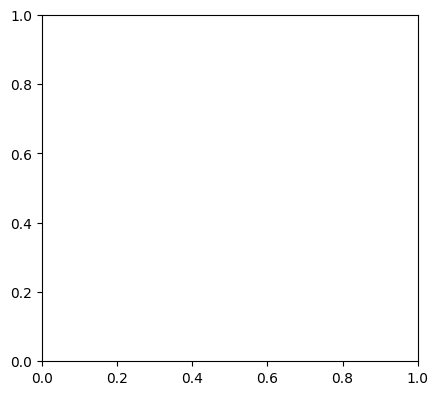

In [10]:
regions = ['Southeast', 'Great Plains', 'California']

fig = plt.figure(figsize=(16.5,4.5))
for num, loc in enumerate(locs):
    ax = plt.subplot(1,3,num+1) 
                     
    df = locals()[f'y_{loc}_era5_test'].sort_values(by='Maximum Precipitation')
    precip = df['Maximum Precipitation']
    
    columns_to_analyze = ['weight_mse_itg_z500', 'weight_mae_itg_z500', 'mse_itg_z500']
    itg_z500 = df[columns_to_analyze].mean(axis=1).values
    columns_to_analyze = ['weight_mse_itg_cwv', 'weight_mae_itg_cwv', 'mse_itg_cwv']
    itg_cwv = df[columns_to_analyze].mean(axis=1).values
    columns_to_analyze = ['weight_mse_itg_tas', 'weight_mae_itg_tas', 'mse_itg_tas']
    itg_tas = df[columns_to_analyze].mean(axis=1).values
    
    itg_tot = itg_z500 + itg_cwv + itg_tas
    
    ax.scatter(precip, itg_z500/itg_tot, color="red")
    ax.scatter(precip, itg_cwv/itg_tot, color='blue')
    ax.scatter(precip, itg_tas/itg_tot, color='orange')

    ax.legend(['Z500', 'CWV', 'TAS'], fontsize=10, loc='upper right')
    ax.set_title(regions[num])
    ax.set_ylabel('Ratio')
    ax.set_xlabel('Precipitation')


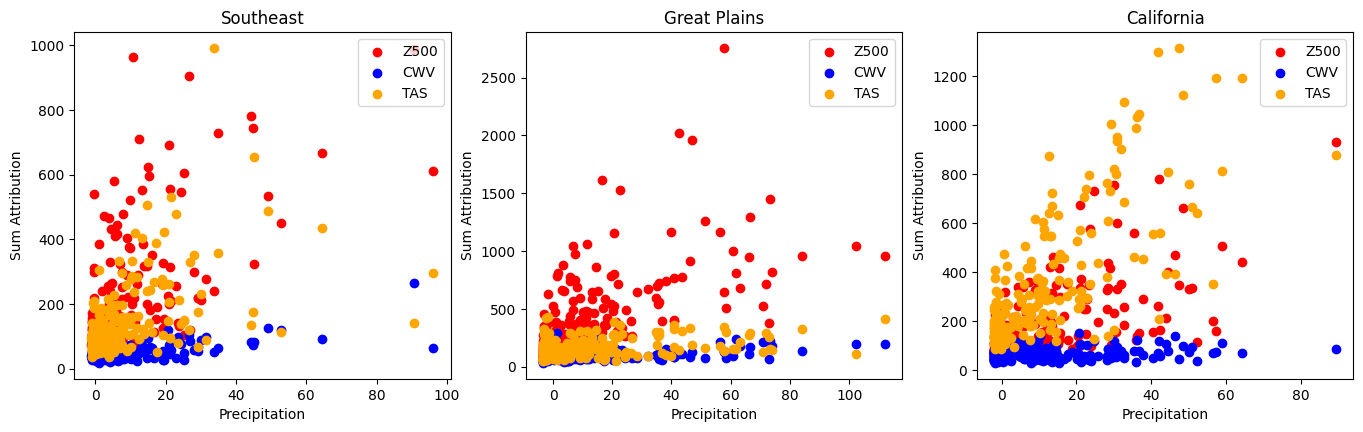

In [7]:
regions = ['Southeast', 'Great Plains', 'California']

fig = plt.figure(figsize=(16.5,4.5))
for num, loc in enumerate(locs):
    ax = plt.subplot(1,3,num+1) 
                     
    df = locals()[f'y_{loc}_era5_test'].sort_values(by='Maximum Precipitation')
    precip = df['Maximum Precipitation']
    
    columns_to_analyze = ['weight_mse_itg_z500', 'weight_mae_itg_z500', 'mse_itg_z500']
    itg_z500 = df[columns_to_analyze].mean(axis=1).values
    columns_to_analyze = ['weight_mse_itg_cwv', 'weight_mae_itg_cwv', 'mse_itg_cwv']
    itg_cwv = df[columns_to_analyze].mean(axis=1).values
    columns_to_analyze = ['weight_mse_itg_tas', 'weight_mae_itg_tas', 'mse_itg_tas']
    itg_tas = df[columns_to_analyze].mean(axis=1).values
    
    ax.scatter(precip, itg_z500, color="red")
    ax.scatter(precip, itg_cwv, color='blue')
    ax.scatter(precip, itg_tas, color='orange')

    ax.legend(['Z500', 'CWV', 'TAS'], fontsize=10, loc='upper right')
    ax.set_title(regions[num])
    ax.set_ylabel('Sum Attribution')
    ax.set_xlabel('Precipitation')


In [14]:
df

,Unnamed: 0,index,Datetimes,Maximum Precipitation,lats,lons,mse_corr,mse_std,mse_error,mse_itg_cwv,...,weight_mse_itg_z500,weight_mse_itg_tas,weight_mae_corr,weight_mae_std,weight_mae_error,weight_mae_itg_cwv,weight_mae_itg_z500,weight_mae_itg_tas,cwv_max,cwv_area
1,1959,9959,2015-12-09,-1.082831,42.1875,253.75,0.031935,0.100492,-158.657716,46.891926,...,105.503190,111.908905,0.059048,0.130722,-206.269484,13.122479,34.32582,72.538680,2.635048,98
109,1352,9352,2011-12-07,-1.075978,33.7500,262.50,0.032661,0.081345,-134.369226,60.702435,...,95.469230,87.922710,0.013497,0.076191,-65.782894,22.349844,45.49355,34.776910,0.378300,11
187,1170,9170,2010-11-06,-1.073568,27.1875,252.50,0.027766,0.081690,-167.051519,45.971794,...,113.800514,128.857350,-0.011829,0.092810,-49.665978,31.509842,37.26753,38.291367,0.380136,9
23,1169,9169,2010-11-05,-1.073548,27.1875,252.50,0.032272,0.092720,-122.847103,104.108960,...,166.350480,134.639420,0.012797,0.105273,-71.703412,54.738735,60.77849,39.556290,0.325469,28
107,1343,9343,2011-11-28,-1.071326,43.1250,253.75,0.065798,0.084518,-214.475836,88.522990,...,151.255580,108.958430,0.015295,0.092577,-92.134665,36.941100,61.49356,56.017105,1.248876,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52,741,8741,2007-12-01,49.203678,37.5000,252.50,0.279046,0.124947,12.018048,124.701004,...,433.538200,396.043120,0.290682,0.103478,11.883621,134.567690,595.32056,530.505250,5.079731,162
45,354,8354,2005-02-05,52.803962,27.1875,252.50,0.259174,0.144375,67.005627,126.421260,...,405.370200,127.537094,0.254671,0.151311,72.606528,103.202230,431.59988,86.594550,2.756307,106
166,705,8705,2007-03-26,64.594278,30.9375,258.75,0.281810,0.167800,33.429358,102.376076,...,543.701900,335.420700,0.447011,0.141465,38.445981,59.162155,770.57490,438.266600,3.571255,162
115,1089,9089,2010-01-15,90.609925,28.1250,262.50,0.433858,0.123548,57.727094,297.340360,...,847.975950,143.047520,0.328868,0.185682,54.205559,290.530850,986.95730,127.625145,1.747500,132


## Correlation + True Precip Val + Stan Dev

In [4]:
def mass_plot_function(df, string1, string2, string3, string4, string5, label1, label2, coef1, coef2):
    '''
    a function that creates a scatter plot with that controls the size and color
    
    df = The pandas dataframe with all the relavent values
    string1 = The x-value on the plot (e.g., mse_corr)
    string2 = The y-value on the plot (e.g., weighted_mse_corr)
    string3 = averaged with string4 to create the size of the scatter point (e.g., mse_std)
    string4 = averaged with string3 to create the size of the scatter point (e.g., weighted_mse_std)
    string5 = controls the color shade of the scatter point
    coef1 = a coefficient that multiplies the size of the scatter point
    coef2 = a coeffiecient that raises the power to the size of the scatter point
    
    returns a scaterplot, more specifically a plt

    '''
    
    idx = np.argsort(df[string1].values)#[::-1]
    size = np.mean(np.array([df[string3].values[idx], df[string4].values[idx]]), axis=0)


    sc = plt.scatter(df[string1].values[idx], df[string2].values[idx],
                     c= df[string5].values, 
                     cmap="Greens", s=(size*coef1)**coef2, edgecolor="k", alpha=0.7, vmax = 100)

    cbar = plt.colorbar(sc)
    cbar.set_label(string5, fontsize=12)

    plt.xlabel(f"{label1} Avg. Correlation", fontsize = 14, fontweight='bold')
    plt.ylabel(f"{label2} Avg. Correlation", fontsize = 14, fontweight='bold')
    
    plt.xlim([-0.09, 0.9])
    plt.ylim([-0.09, 0.9])
    plt.grid()
    
    return plt


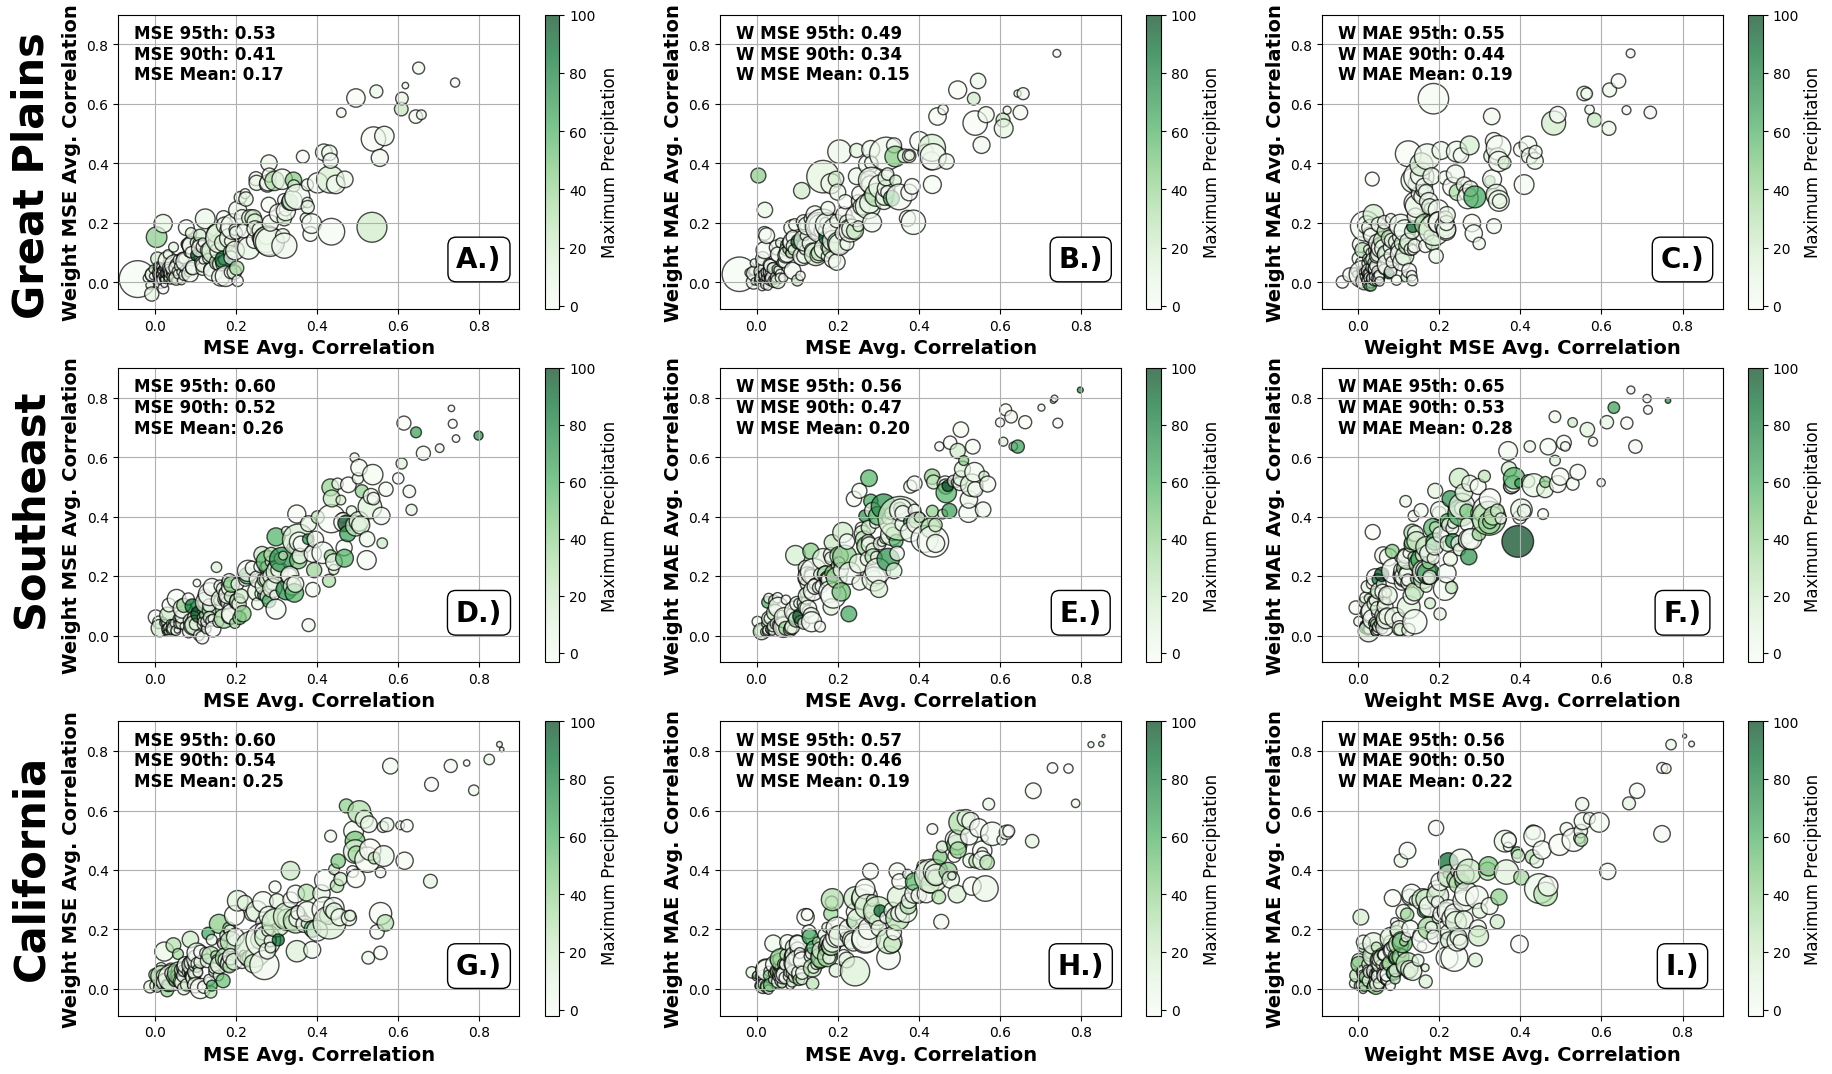

In [22]:
locs = ['gp', 'se', 'ca']


fig = plt.figure(figsize=(22, 13))

labels1 = ['MSE', 'MSE', 'Weight MSE']
labels2 = ['Weight MSE', 'Weight MAE', 'Weight MAE']
labels3 = ['MSE', 'W MSE', 'W MAE']

fuct1 = ['mse', 'mse', 'weight_mse']
fuct2 = ['weight_mse', 'weight_mae', 'weight_mae']
fuct3 = ['mse', 'weight_mse', 'weight_mae']

abc = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']

j = 1

for loc_num, loc in enumerate(locs):
    for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(3,3, j)
        j+=1

        plt = mass_plot_function(locals()[f'y_{loc}_era5_test'], f'{fuct1[fuct_num]}_corr', f'{fuct2[fuct_num]}_corr',
                                 f'{fuct1[fuct_num]}_std', f'{fuct2[fuct_num]}_std', 'Maximum Precipitation',
                                 labels1[fuct_num], labels2[fuct_num], 50, 2.5)
        
        plt.annotate(f'{labels3[fuct_num]} 95th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.95))[:4]}',
                     xy=(0.04,0.92), xycoords='axes fraction', fontsize=12, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} 90th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.9))[:4]}',
                     xy=(0.04,0.85), xycoords='axes fraction', fontsize=12, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} Mean: {str(np.mean(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].values))[:4]}',
                     xy=(0.04,0.78), xycoords='axes fraction', fontsize=12, fontweight='bold')
        plt.annotate(f'{abc[j-2]}.)', (0.8, 0.05), textcoords="offset points",  color='k', fontsize=20, xytext=(0, 0), ha='center',
                     bbox=dict(boxstyle='round', facecolor='w', alpha=1), fontweight='bold')
        

plt.annotate('Great Plains', xy=(-3.27,2.4), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')
plt.annotate('Southeast', xy=(-3.27,1.35), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')
plt.annotate('California', xy=(-3.27,0.15), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')

plt.savefig(f'all_regions_corr.png', format='png', dpi=500, bbox_inches='tight')

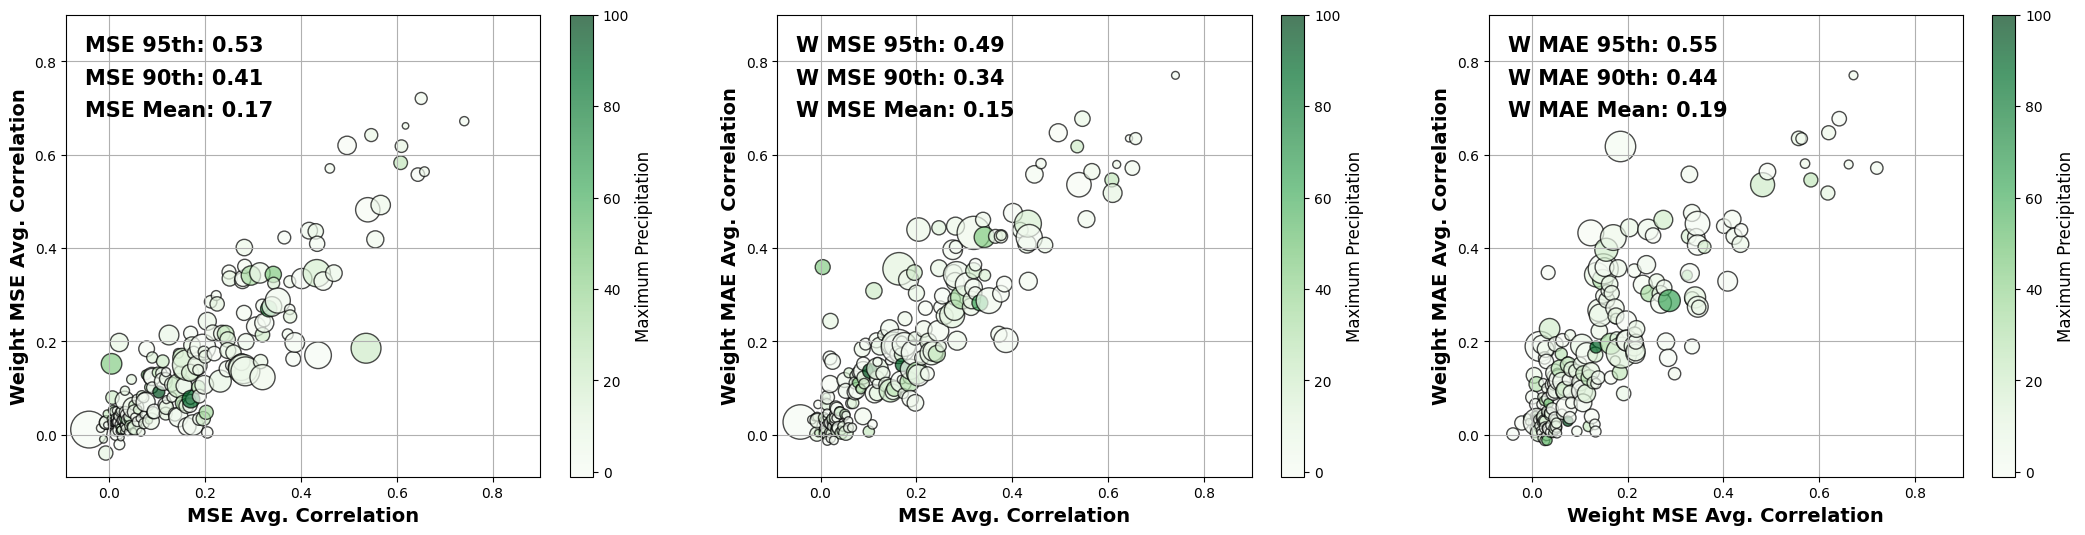

In [43]:
fig = plt.figure(figsize=(26, 6))
loc = 'gp'

for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(1,3, fuct_num+1)
        
        plt = mass_plot_function(locals()[f'y_{loc}_era5_test'], f'{fuct1[fuct_num]}_corr', f'{fuct2[fuct_num]}_corr',
                           f'{fuct1[fuct_num]}_std', f'{fuct2[fuct_num]}_std', 'Maximum Precipitation',
                           labels1[fuct_num], labels2[fuct_num], 50, 2.5)
        
        plt.annotate(f'{labels3[fuct_num]} 95th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.95))[:4]}',
                     xy=(0.04,0.92), xycoords='axes fraction', fontsize=15, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} 90th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.9))[:4]}',
                     xy=(0.04,0.85), xycoords='axes fraction', fontsize=15, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} Mean: {str(np.mean(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].values))[:4]}',
                     xy=(0.04,0.78), xycoords='axes fraction', fontsize=15, fontweight='bold')
        
        
plt.savefig(f'{loc}_corr.png', format='png', dpi=500, bbox_inches='tight')

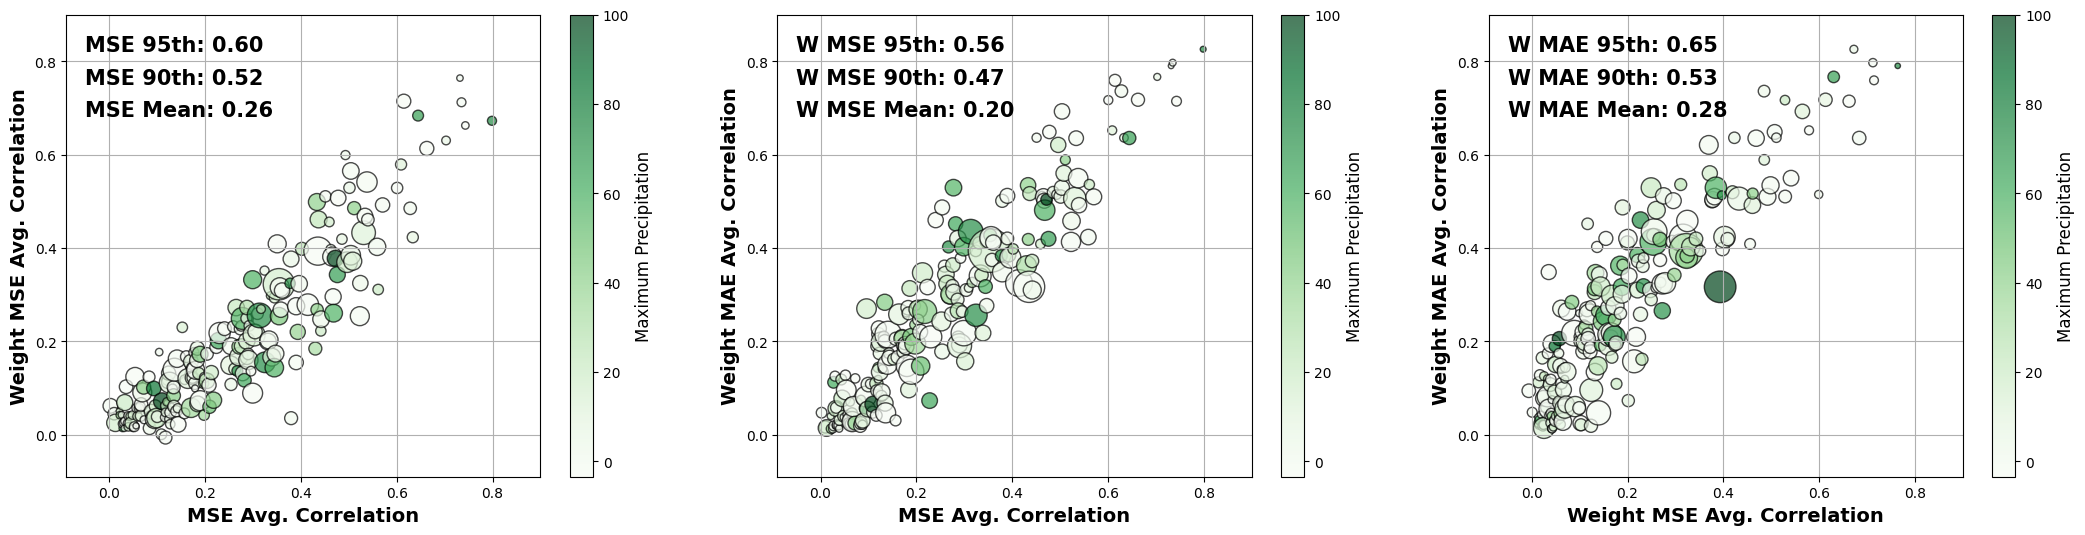

In [44]:
fig = plt.figure(figsize=(26, 6))
loc = 'se'

for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(1,3, fuct_num+1)
        
        mass_plot_function(locals()[f'y_{loc}_era5_test'], f'{fuct1[fuct_num]}_corr', f'{fuct2[fuct_num]}_corr',
                           f'{fuct1[fuct_num]}_std', f'{fuct2[fuct_num]}_std', 'Maximum Precipitation',
                           labels1[fuct_num], labels2[fuct_num], 50, 2.5)
        
        plt.annotate(f'{labels3[fuct_num]} 95th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.95))[:4]}',
                     xy=(0.04,0.92), xycoords='axes fraction', fontsize=15, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} 90th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.9))[:4]}',
                     xy=(0.04,0.85), xycoords='axes fraction', fontsize=15, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} Mean: {str(np.mean(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].values))[:4]}',
                     xy=(0.04,0.78), xycoords='axes fraction', fontsize=15, fontweight='bold')
        
        
plt.savefig(f'{loc}_corr.png', format='png', dpi=500, bbox_inches='tight')

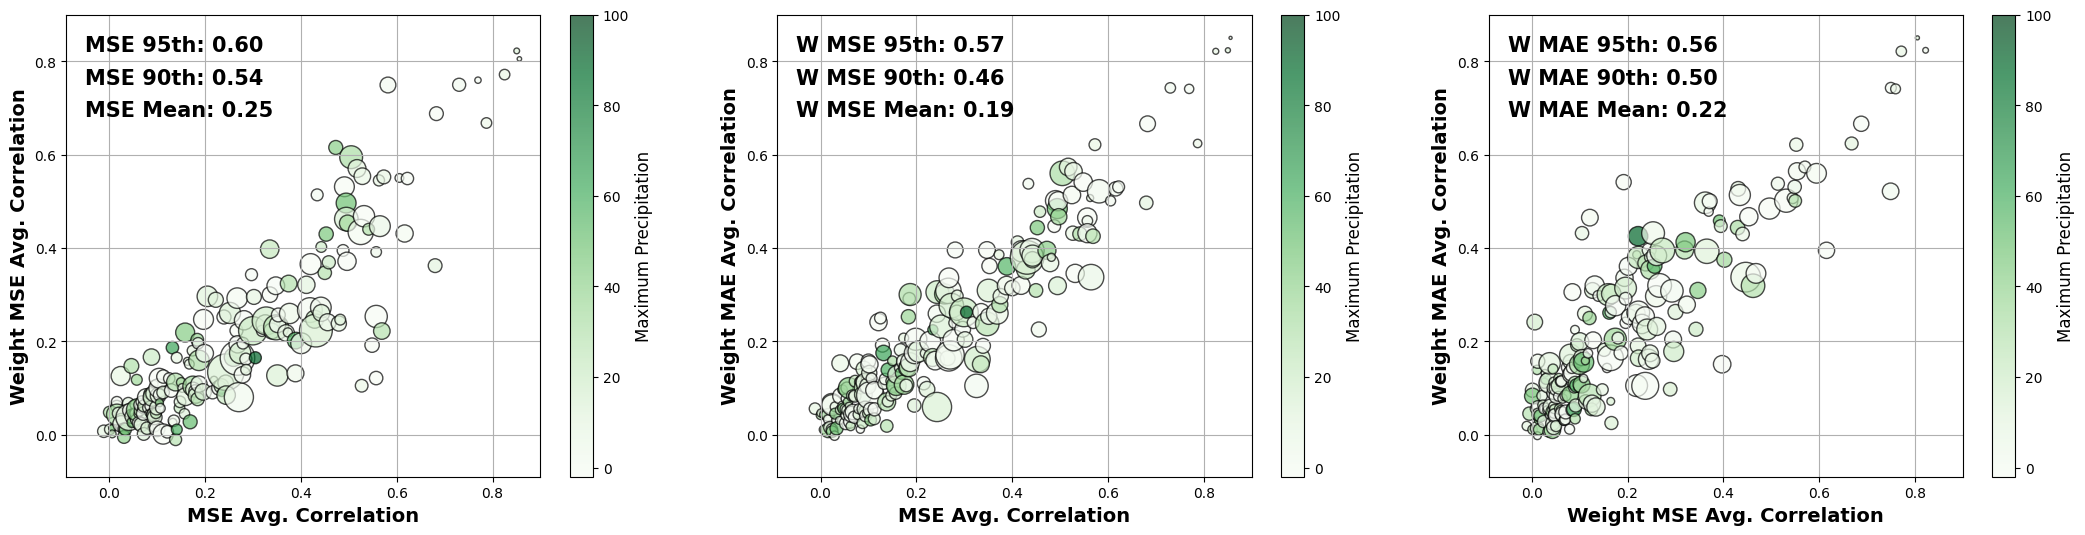

In [45]:
fig = plt.figure(figsize=(26, 6))
loc = 'ca'

for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(1,3, fuct_num+1)
        
        mass_plot_function(locals()[f'y_{loc}_era5_test'], f'{fuct1[fuct_num]}_corr', f'{fuct2[fuct_num]}_corr',
                           f'{fuct1[fuct_num]}_std', f'{fuct2[fuct_num]}_std', 'Maximum Precipitation',
                           labels1[fuct_num], labels2[fuct_num], 50, 2.5)
        
        plt.annotate(f'{labels3[fuct_num]} 95th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.95))[:4]}',
                     xy=(0.04,0.92), xycoords='axes fraction', fontsize=15, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} 90th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.9))[:4]}',
                     xy=(0.04,0.85), xycoords='axes fraction', fontsize=15, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} Mean: {str(np.mean(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].values))[:4]}',
                     xy=(0.04,0.78), xycoords='axes fraction', fontsize=15, fontweight='bold')
        
plt.savefig(f'{loc}_corr.png', format='png', dpi=500, bbox_inches='tight')

In [36]:
### Correlation + True Precip val + cwv area

Text(-3.27, 0.15, 'California')

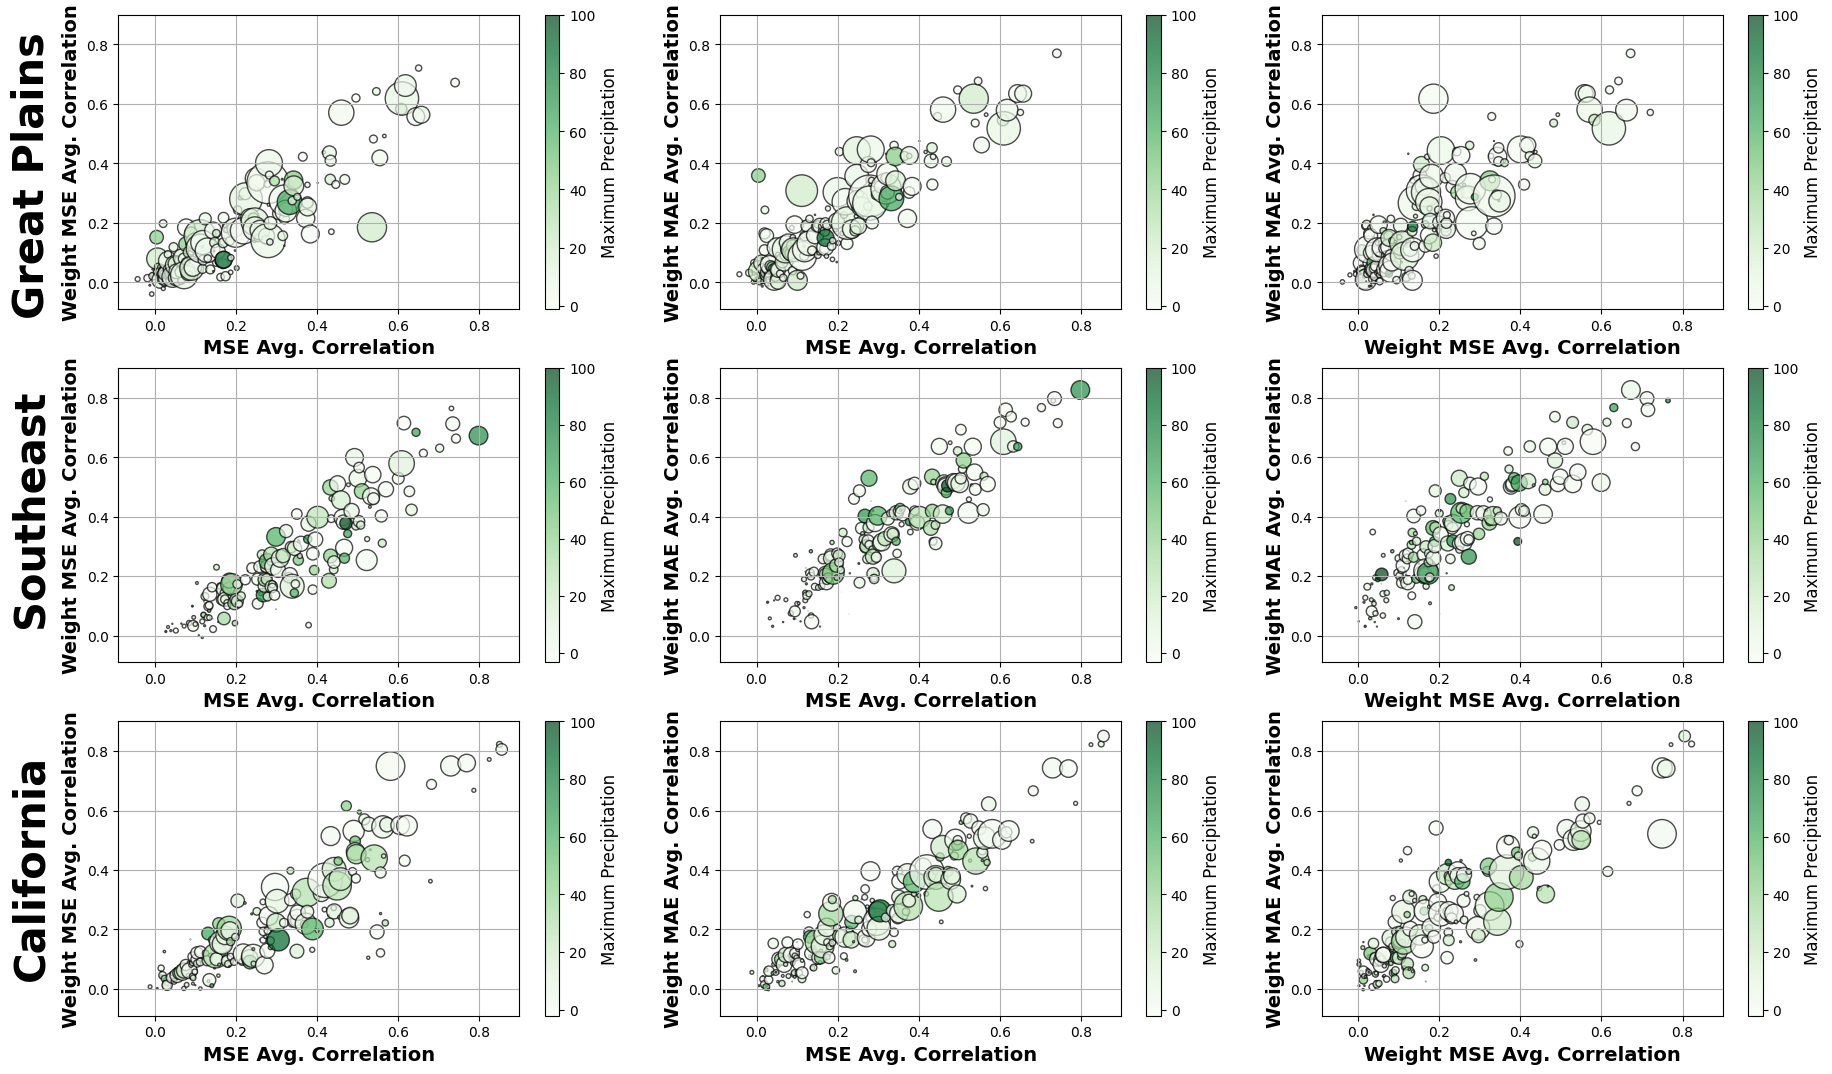

In [49]:
locs = ['gp', 'se', 'ca']


fig = plt.figure(figsize=(22, 13))

labels1 = ['MSE', 'MSE', 'Weight MSE']
labels2 = ['Weight MSE', 'Weight MAE', 'Weight MAE']

fuct1 = ['mse', 'mse', 'weight_mse']
fuct2 = ['weight_mse', 'weight_mae', 'weight_mae']

j = 1

for loc_num, loc in enumerate(locs):
    for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(3,3, j)
        j+=1

        mass_plot_function(locals()[f'y_{loc}_era5_test'], f'{fuct1[fuct_num]}_corr', f'{fuct2[fuct_num]}_corr',
                           f'cwv_max', f'cwv_max', 'Maximum Precipitation',
                           labels1[fuct_num], labels2[fuct_num], 3, 2.5)
        

plt.annotate('Great Plains', xy=(-3.27,2.4), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')
plt.annotate('Southeast', xy=(-3.27,1.35), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')
plt.annotate('California', xy=(-3.27,0.15), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')

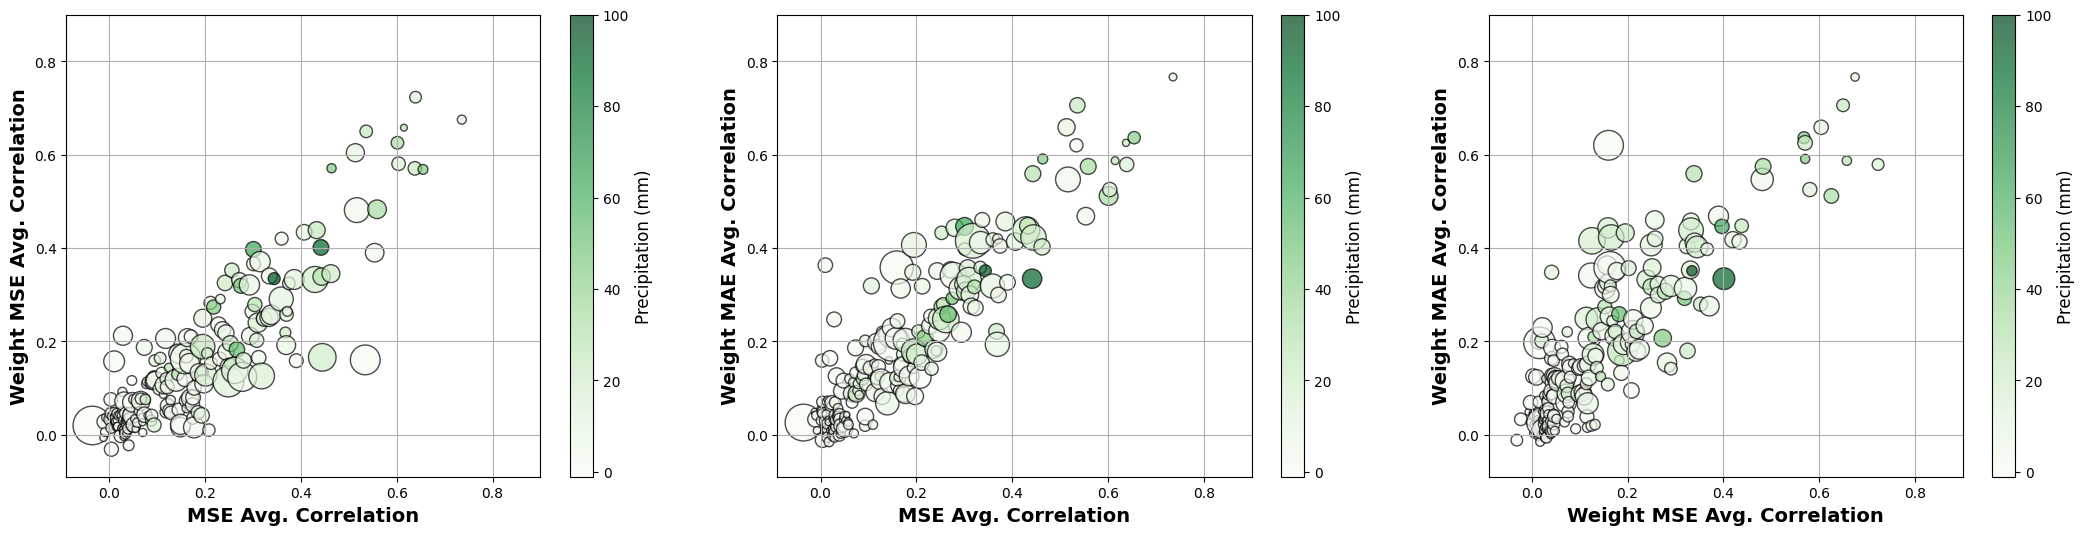

In [32]:
fig = plt.figure(figsize=(26, 6))
loc = 'gp'

for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(1,3, fuct_num+1)

        mass_plot_function(locals()[f'{fuct1[fuct_num]}_avg_{loc}'], locals()[f'{fuct2[fuct_num]}_avg_{loc}'],
                           locals()[f'{fuct1[fuct_num]}_std_{loc}'], locals()[f'{fuct2[fuct_num]}_std_{loc}'],
                           locals()[f'y_{loc}_era5_test'], labels1[fuct_num], labels2[fuct_num])
        
plt.savefig(f'{loc}_corr.png', format='png', dpi=500, bbox_inches='tight')
        

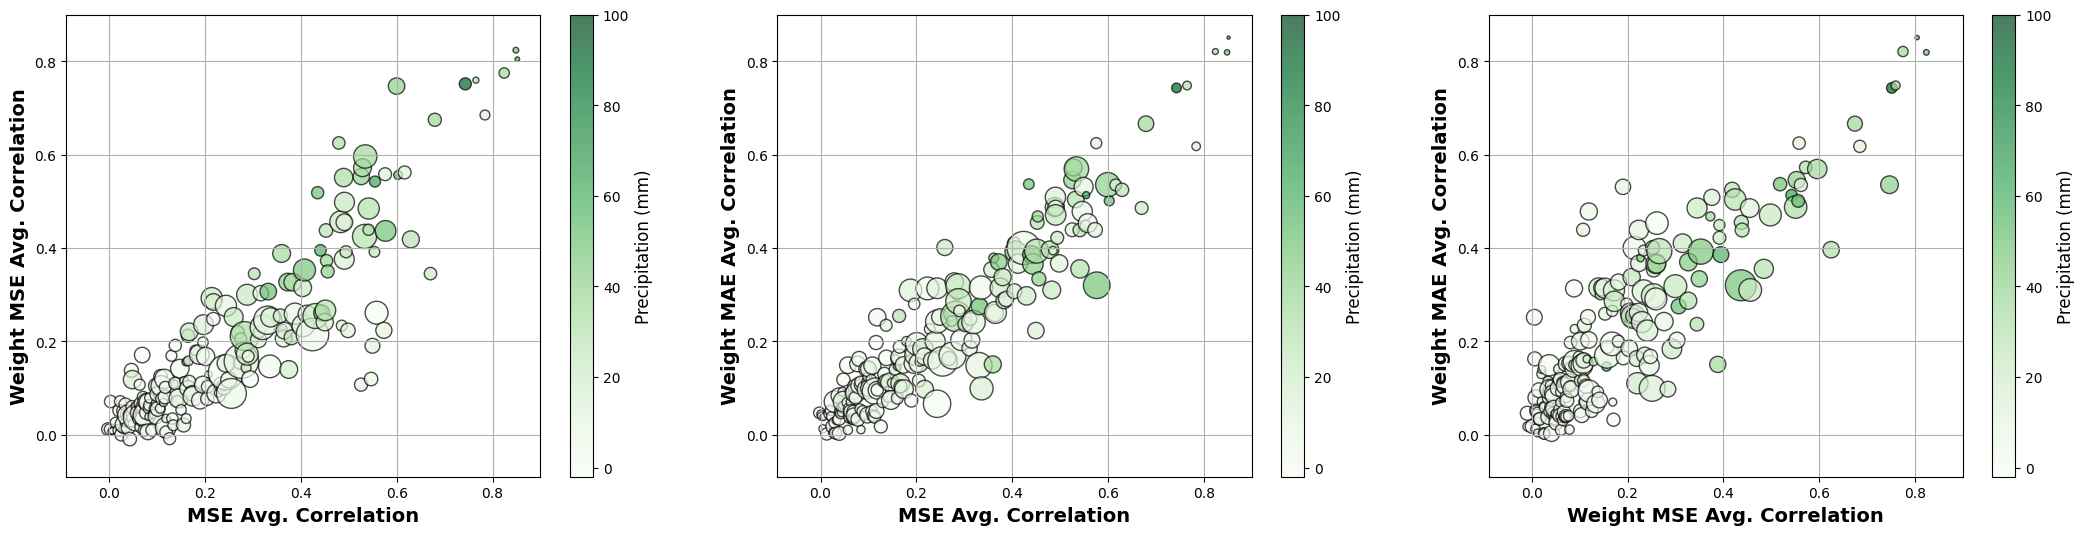

In [33]:
fig = plt.figure(figsize=(26, 6))
loc = 'ca'

for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(1,3, fuct_num+1)

        mass_plot_function(locals()[f'{fuct1[fuct_num]}_avg_{loc}'], locals()[f'{fuct2[fuct_num]}_avg_{loc}'],
                           locals()[f'{fuct1[fuct_num]}_std_{loc}'], locals()[f'{fuct2[fuct_num]}_std_{loc}'],
                           locals()[f'y_{loc}_era5_test'], labels1[fuct_num], labels2[fuct_num])
        
plt.savefig(f'{loc}_corr.png', format='png', dpi=500, bbox_inches='tight')
        

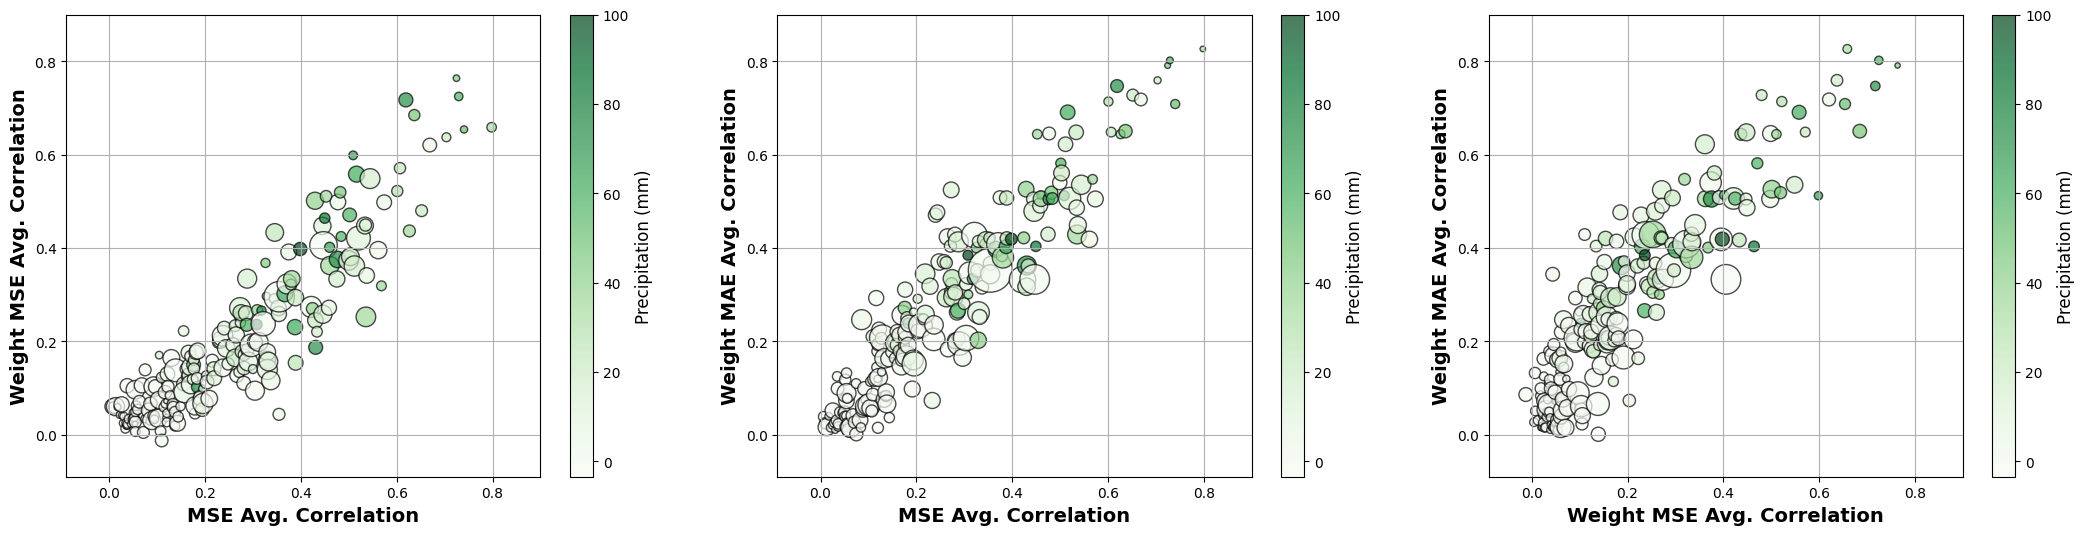

In [34]:
fig = plt.figure(figsize=(26, 6))
loc = 'se'

for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(1,3, fuct_num+1)

        mass_plot_function(locals()[f'{fuct1[fuct_num]}_avg_{loc}'], locals()[f'{fuct2[fuct_num]}_avg_{loc}'],
                           locals()[f'{fuct1[fuct_num]}_std_{loc}'], locals()[f'{fuct2[fuct_num]}_std_{loc}'],
                           locals()[f'y_{loc}_era5_test'], labels1[fuct_num], labels2[fuct_num])
        
plt.savefig(f'{loc}_corr.png', format='png', dpi=500, bbox_inches='tight')
        

In [ ]:
### Z500 ITG Size

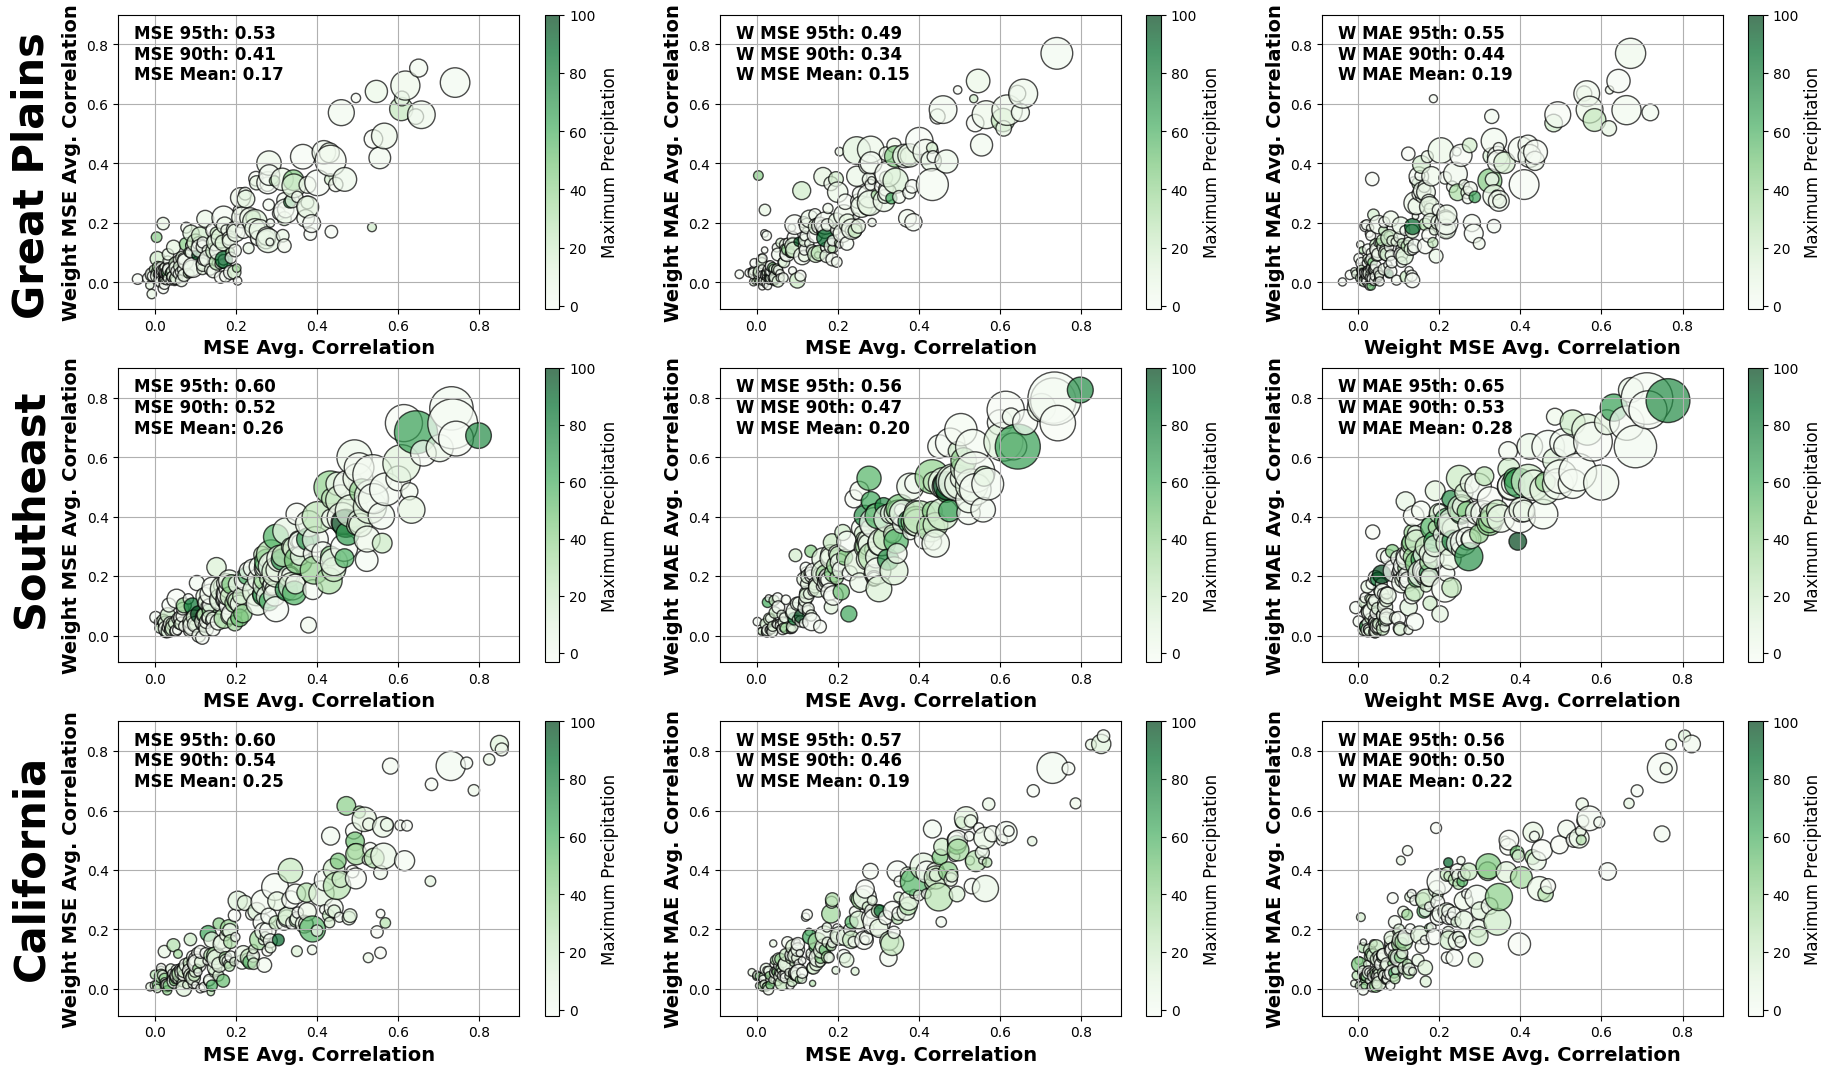

In [51]:
fig = plt.figure(figsize=(22, 13))

labels1 = ['MSE', 'MSE', 'Weight MSE']
labels2 = ['Weight MSE', 'Weight MAE', 'Weight MAE']
labels3 = ['MSE', 'W MSE', 'W MAE']

fuct1 = ['mse', 'mse', 'weight_mse']
fuct2 = ['weight_mse', 'weight_mae', 'weight_mae']
fuct3 = ['mse', 'weight_mse', 'weight_mae']

j = 1

for loc_num, loc in enumerate(locs):
    for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(3,3, j)
        j+=1

        plt = mass_plot_function(locals()[f'y_{loc}_era5_test'], f'{fuct1[fuct_num]}_corr', f'{fuct2[fuct_num]}_corr',
                                 f'{fuct1[fuct_num]}_itg_z500', f'{fuct2[fuct_num]}_itg_z500', 'Maximum Precipitation',
                                 labels1[fuct_num], labels2[fuct_num], .5, 1)
        
        plt.annotate(f'{labels3[fuct_num]} 95th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.95))[:4]}',
                     xy=(0.04,0.92), xycoords='axes fraction', fontsize=12, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} 90th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.9))[:4]}',
                     xy=(0.04,0.85), xycoords='axes fraction', fontsize=12, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} Mean: {str(np.mean(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].values))[:4]}',
                     xy=(0.04,0.78), xycoords='axes fraction', fontsize=12, fontweight='bold')
        

plt.annotate('Great Plains', xy=(-3.27,2.4), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')
plt.annotate('Southeast', xy=(-3.27,1.35), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')
plt.annotate('California', xy=(-3.27,0.15), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')

plt.savefig(f'regions_corr.png', format='png', dpi=500, bbox_inches='tight')

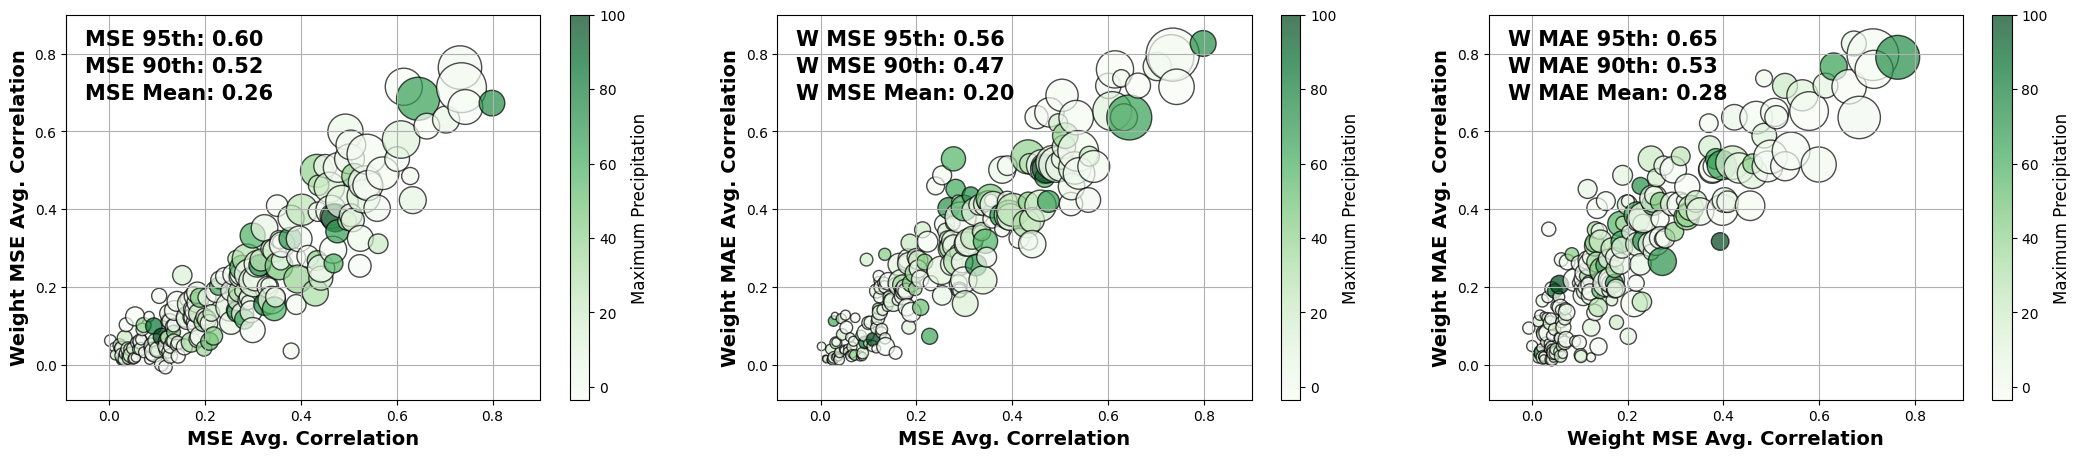

In [59]:
fig = plt.figure(figsize=(26, 5))
loc = 'se'

for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(1,3, fuct_num+1)

        plt = mass_plot_function(locals()[f'y_{loc}_era5_test'], f'{fuct1[fuct_num]}_corr', f'{fuct2[fuct_num]}_corr',
                                 f'{fuct1[fuct_num]}_itg_z500', f'{fuct2[fuct_num]}_itg_z500', 'Maximum Precipitation',
                                 labels1[fuct_num], labels2[fuct_num], .5, 1)
        
        plt.annotate(f'{labels3[fuct_num]} 95th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.95))[:4]}',
                     xy=(0.04,0.92), xycoords='axes fraction', fontsize=15, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} 90th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.9))[:4]}',
                     xy=(0.04,0.85), xycoords='axes fraction', fontsize=15, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} Mean: {str(np.mean(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].values))[:4]}',
                     xy=(0.04,0.78), xycoords='axes fraction', fontsize=15, fontweight='bold')
        

In [60]:
###

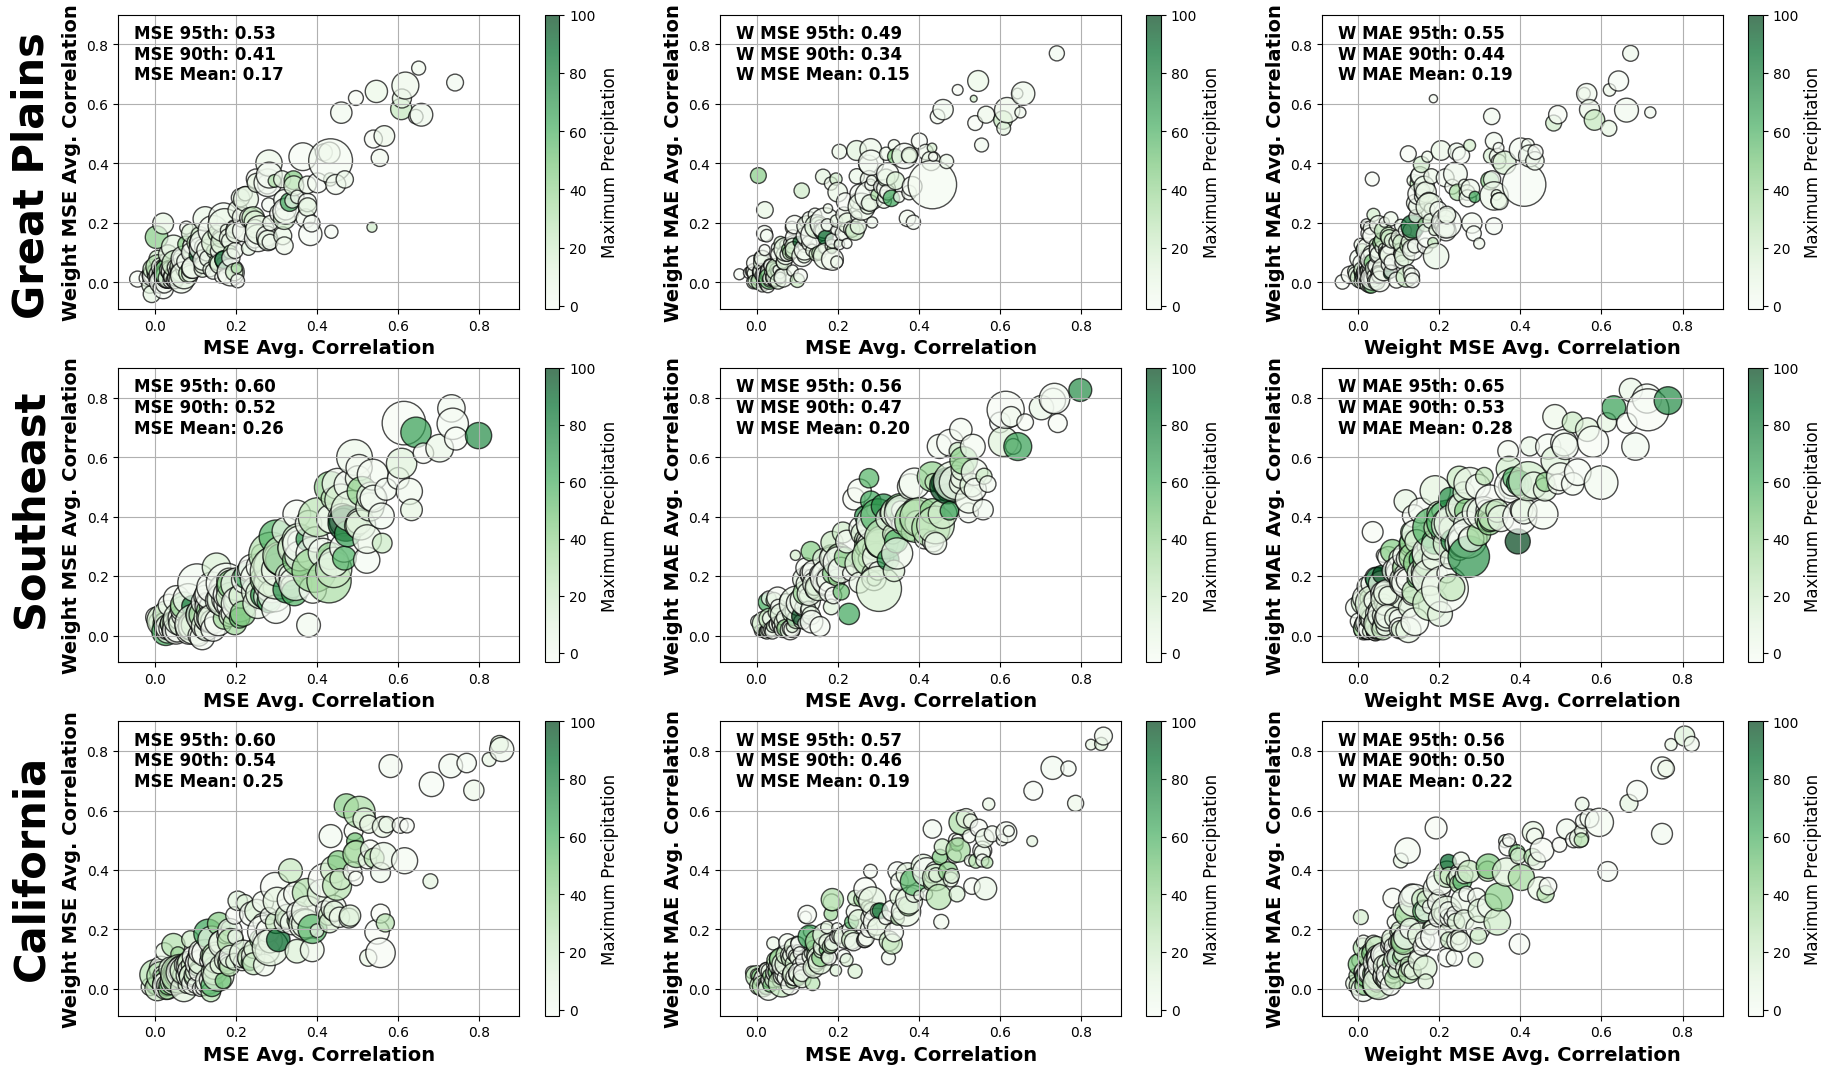

In [64]:
fig = plt.figure(figsize=(22, 13))

labels1 = ['MSE', 'MSE', 'Weight MSE']
labels2 = ['Weight MSE', 'Weight MAE', 'Weight MAE']
labels3 = ['MSE', 'W MSE', 'W MAE']

fuct1 = ['mse', 'mse', 'weight_mse']
fuct2 = ['weight_mse', 'weight_mae', 'weight_mae']
fuct3 = ['mse', 'weight_mse', 'weight_mae']

j = 1

for loc_num, loc in enumerate(locs):
    for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(3,3, j)
        j+=1

        plt = mass_plot_function(locals()[f'y_{loc}_era5_test'], f'{fuct1[fuct_num]}_corr', f'{fuct2[fuct_num]}_corr',
                                 f'{fuct1[fuct_num]}_itg_cwv', f'{fuct2[fuct_num]}_itg_cwv', 'Maximum Precipitation',
                                 labels1[fuct_num], labels2[fuct_num], 1, 1.25)
        
        plt.annotate(f'{labels3[fuct_num]} 95th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.95))[:4]}',
                     xy=(0.04,0.92), xycoords='axes fraction', fontsize=12, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} 90th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.9))[:4]}',
                     xy=(0.04,0.85), xycoords='axes fraction', fontsize=12, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} Mean: {str(np.mean(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].values))[:4]}',
                     xy=(0.04,0.78), xycoords='axes fraction', fontsize=12, fontweight='bold')
        

plt.annotate('Great Plains', xy=(-3.27,2.4), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')
plt.annotate('Southeast', xy=(-3.27,1.35), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')
plt.annotate('California', xy=(-3.27,0.15), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')

plt.savefig(f'regions_corr.png', format='png', dpi=500, bbox_inches='tight')

In [ ]:
### MJO and NINO Vals

In [81]:
def mass_plot_function(df, string1, string2, string3, string4, string5, label1, label2, coef1, coef2):
    '''
    a function that creates a scatter plot with that controls the size and color
    
    df = The pandas dataframe with all the relavent values
    string1 = The x-value on the plot (e.g., mse_corr)
    string2 = The y-value on the plot (e.g., weighted_mse_corr)
    string3 = averaged with string4 to create the size of the scatter point (e.g., mse_std)
    string4 = averaged with string3 to create the size of the scatter point (e.g., weighted_mse_std)
    string5 = controls the color shade of the scatter point
    coef1 = a coefficient that multiplies the size of the scatter point
    coef2 = a coeffiecient that raises the power to the size of the scatter point
    
    returns a scaterplot, more specifically a plt

    '''
    
    idx = np.argsort(df[string1].values)#[::-1]
    size = np.mean(np.array([df[string3].values[idx], df[string4].values[idx]]), axis=0)


    sc = plt.scatter(df[string1].values[idx], df[string2].values[idx],
                     c= df[string5].values, 
                     cmap="coolwarm", s=(size*coef1)**coef2, edgecolor="k", alpha=0.7, vmin=-3, vmax = 3)

    cbar = plt.colorbar(sc)
    cbar.set_label(string5, fontsize=12)

    plt.xlabel(f"{label1} Avg. Correlation", fontsize = 14, fontweight='bold')
    plt.ylabel(f"{label2} Avg. Correlation", fontsize = 14, fontweight='bold')
    
    plt.xlim([-0.09, 0.9])
    plt.ylim([-0.09, 0.9])
    plt.grid()
    
    return plt


Text(-3.27, 0.15, 'California')

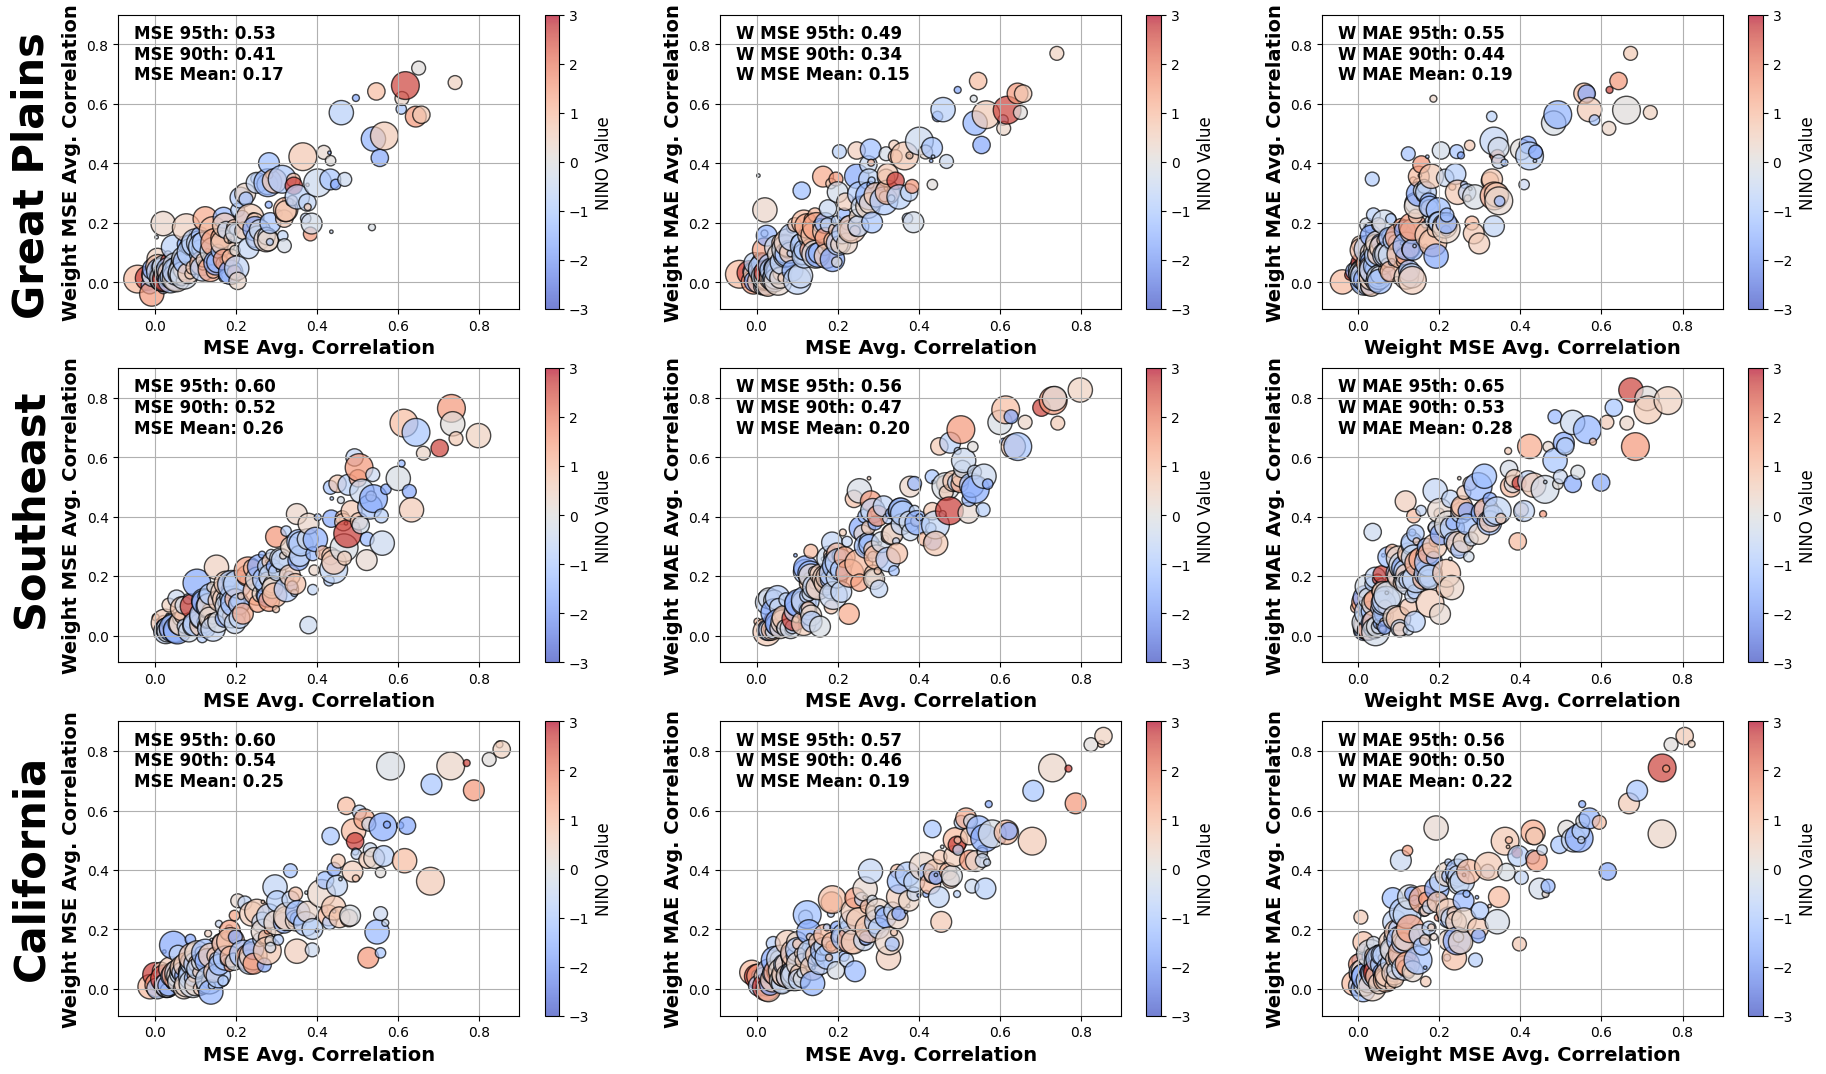

In [82]:
fig = plt.figure(figsize=(22, 13))

labels1 = ['MSE', 'MSE', 'Weight MSE']
labels2 = ['Weight MSE', 'Weight MAE', 'Weight MAE']
labels3 = ['MSE', 'W MSE', 'W MAE']

fuct1 = ['mse', 'mse', 'weight_mse']
fuct2 = ['weight_mse', 'weight_mae', 'weight_mae']
fuct3 = ['mse', 'weight_mse', 'weight_mae']

j = 1

for loc_num, loc in enumerate(locs):
    for fuct_num in range(len(fuct1)):
    
        ax = plt.subplot(3,3, j)
        j+=1

        plt = mass_plot_function(locals()[f'y_{loc}_era5_test'], f'{fuct1[fuct_num]}_corr', f'{fuct2[fuct_num]}_corr',
                                 'MJO Phase', 'MJO Phase', 'NINO Value',
                                 labels1[fuct_num], labels2[fuct_num], 2.5, 2)
        
        plt.annotate(f'{labels3[fuct_num]} 95th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.95))[:4]}',
                     xy=(0.04,0.92), xycoords='axes fraction', fontsize=12, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} 90th: {str(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].quantile(.9))[:4]}',
                     xy=(0.04,0.85), xycoords='axes fraction', fontsize=12, fontweight='bold')
        plt.annotate(f'{labels3[fuct_num]} Mean: {str(np.mean(locals()[f"y_{loc}_era5_test"][f"{fuct3[fuct_num]}_corr"].values))[:4]}',
                     xy=(0.04,0.78), xycoords='axes fraction', fontsize=12, fontweight='bold')
        

plt.annotate('Great Plains', xy=(-3.27,2.4), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')
plt.annotate('Southeast', xy=(-3.27,1.35), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')
plt.annotate('California', xy=(-3.27,0.15), xycoords='axes fraction', fontsize=30, rotation='vertical', fontweight='bold')


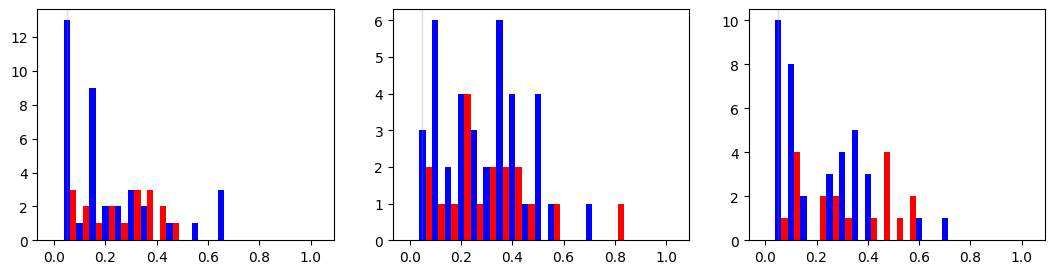

In [134]:
start = 0.05

fig = plt.figure(figsize=(13, 3))

for num1, loc in enumerate(locs):
    ax = plt.subplot(1,3, num1+1)
    
    df = locals()[f'y_{loc}_era5_test']
    avg = df[['mse_corr', 'weight_mse_corr', 'weight_mae_corr']].mean(axis=1).values

    for val in np.arange(0, 1.01, start):
        df_cur = df[((avg <= val) & (avg>val-start))].copy()
        plt.bar(val, len(df_cur[df_cur['NINO Value'].values <= - 1]), width=start/2, color = 'blue')
        plt.bar(val+start/2, len(df_cur[df_cur['NINO Value'].values >= 1]), width=start/2, color = 'red')
        
    plt.axvspan(0.05, 0.05, color='grey', alpha=0.25)

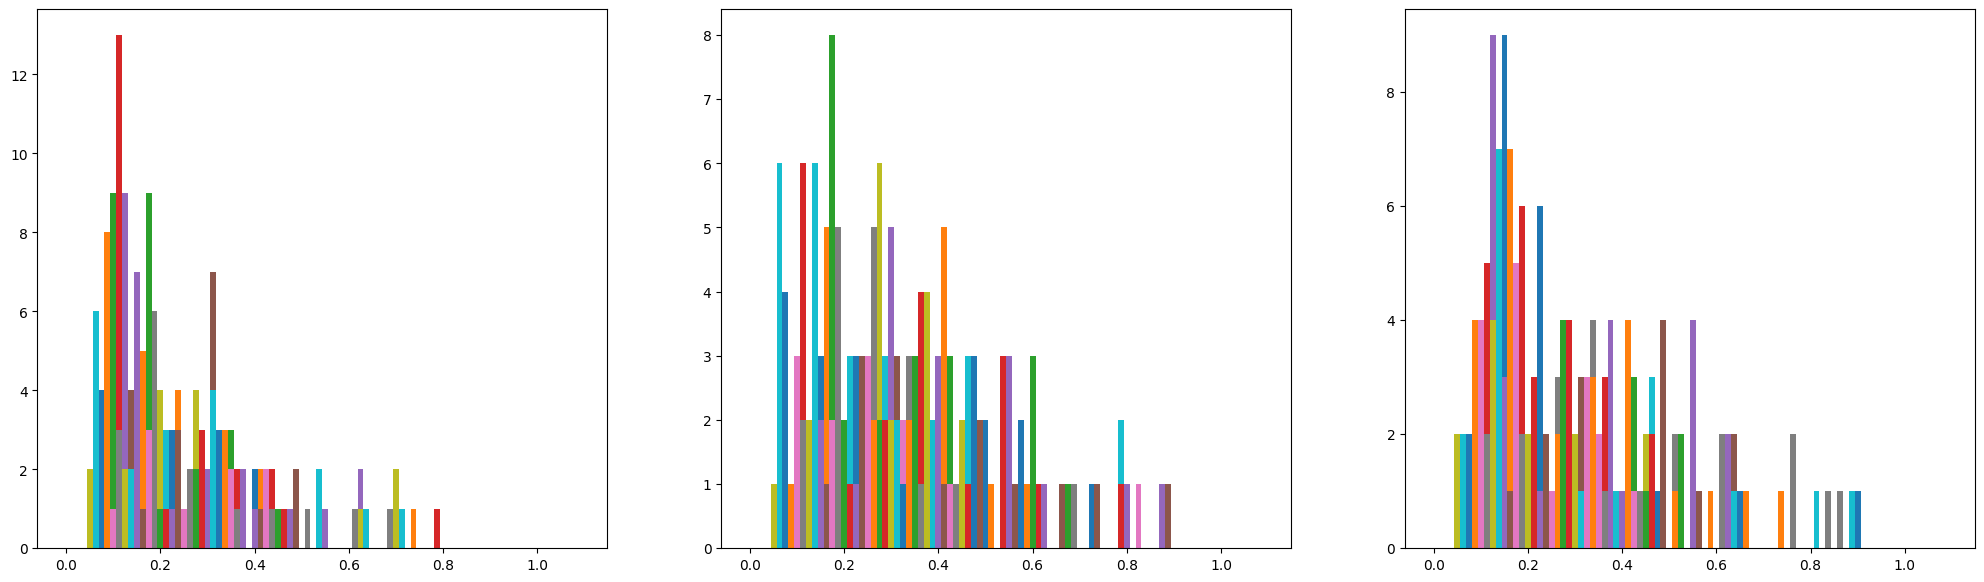

In [144]:
fig = plt.figure(figsize=(25, 7))

for num1, loc in enumerate(locs):
    ax = plt.subplot(1,3, num1+1)
    
    df = locals()[f'y_{loc}_era5_test']
    avg = df[['mse_corr', 'weight_mse_corr', 'weight_mae_corr']].mean(axis=1).values

    for val in np.arange(0, 1.01, start):
        df_cur = df[((avg <= val) & (avg>val-start))].copy()
        
        for phase in np.arange(1,9,1):
            plt.bar(val + ((phase - 1)*1/80), len(df_cur[df_cur['MJO Phase'].values == phase]), width=1/80)

In [ ]:
for num1, loc in enumerate(locs):
    ax = plt.subplot(1,3, num1+1)
    
    df = locals()[f'y_{loc}_era5_test']
    avg = df[['mse_corr', 'weight_mse_corr', 'weight_mae_corr']].mean(axis=1).values

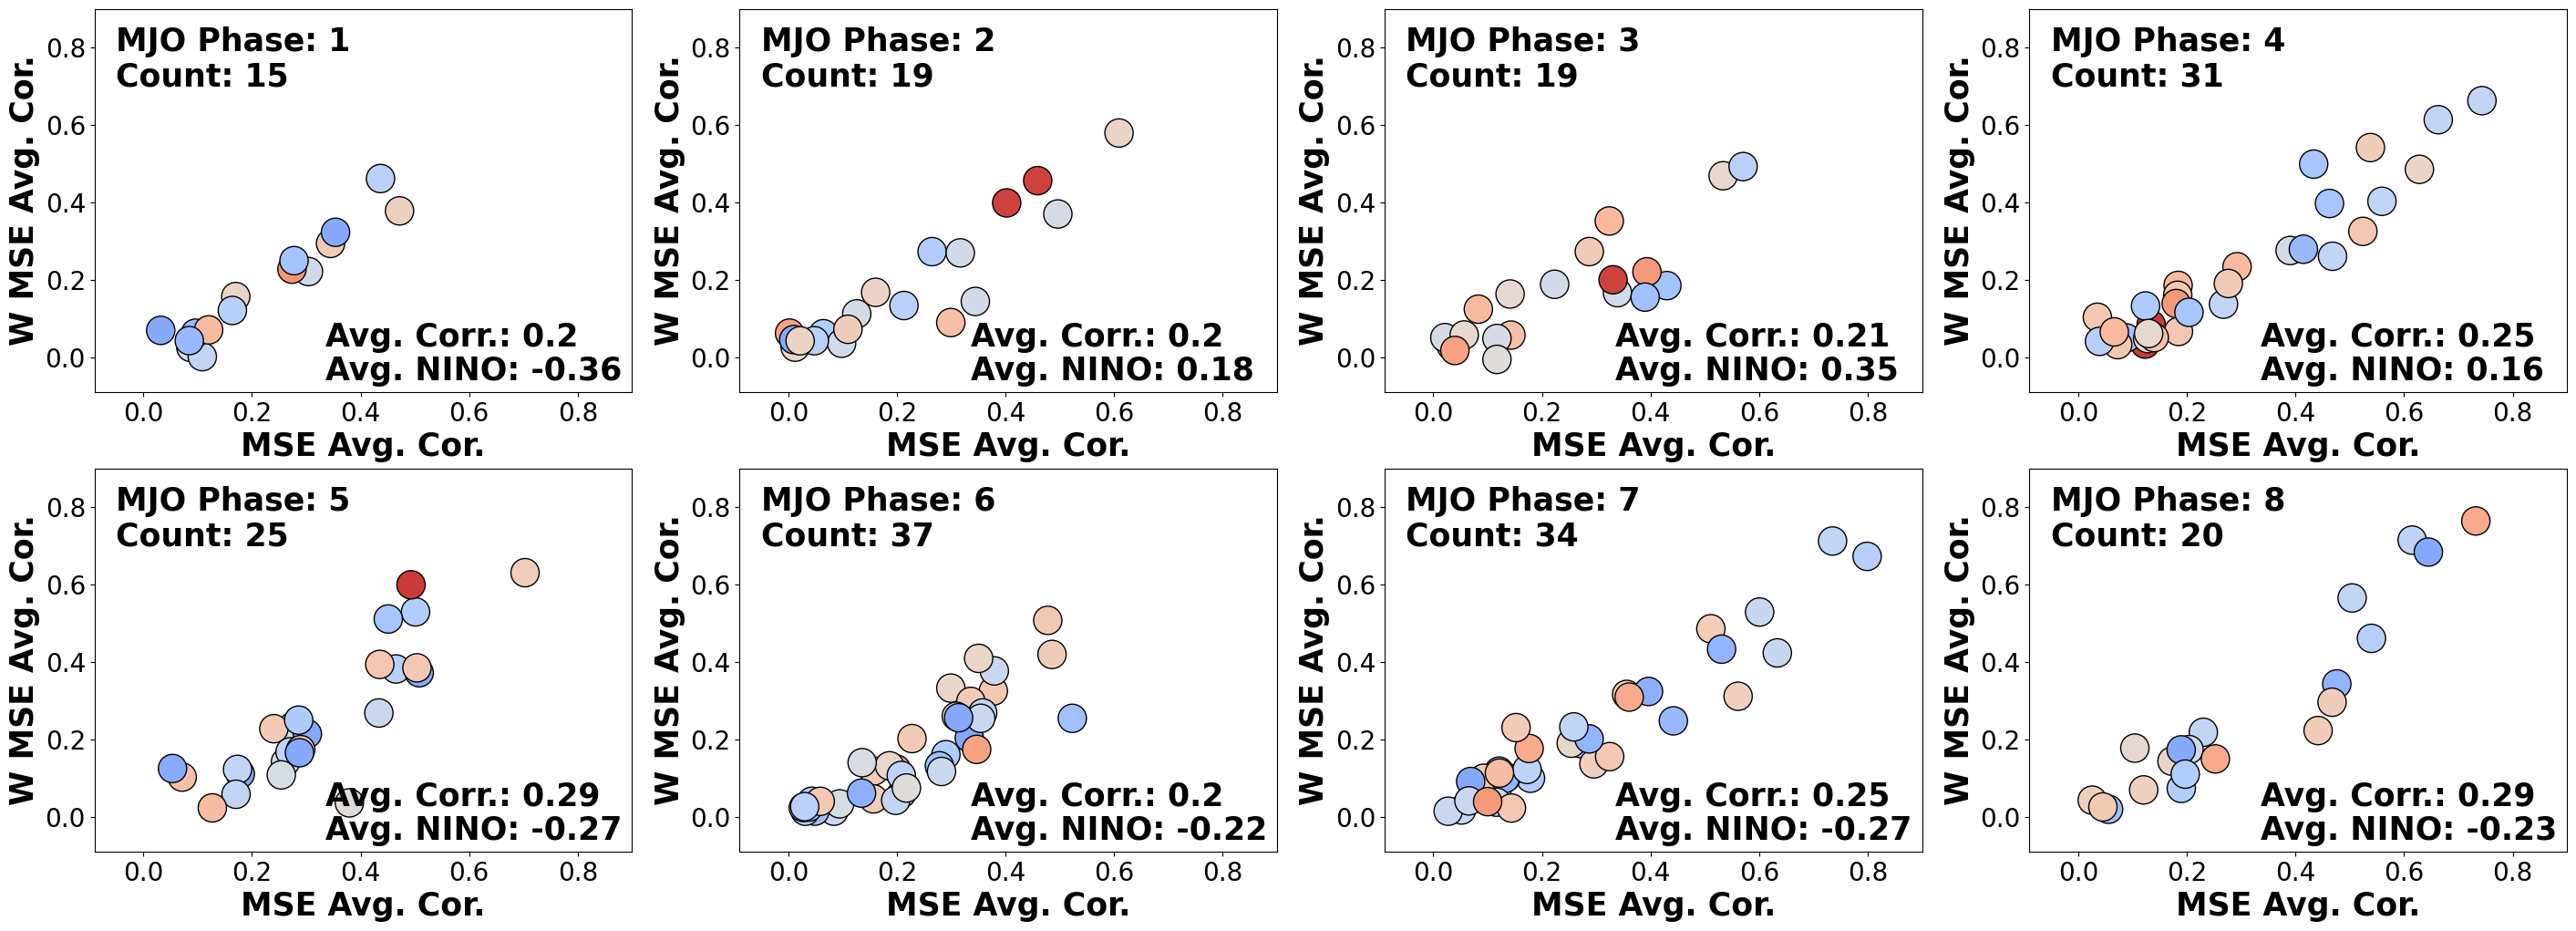

In [11]:
loc = 'se'
df = locals()[f'y_{loc}_era5_test']

fig = plt.figure(figsize=(35, 12))

for phase in np.arange(1, 9, 1):
    ax = plt.subplot(2,4, phase)
    
    df_cur = df[df['MJO Phase'].values == phase]
    plt.scatter(df_cur['mse_corr'].values, df_cur['weight_mse_corr'].values, 
                c=df_cur['NINO Value'].values, cmap='coolwarm', vmin=-3, vmax = 3,
               edgecolor='k', s=500)
    
    plt.xlim([-0.09, 0.9])
    plt.ylim([-0.09, 0.9])
    
    plt.xlabel(f"MSE Avg. Cor.", fontsize = 25, fontweight='bold')
    plt.ylabel(f"W MSE Avg. Cor.", fontsize = 25, fontweight='bold')
    
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    plt.annotate(f'MJO Phase: {phase}',xy=(0.04,0.89), xycoords='axes fraction', fontsize=25, fontweight='bold')
    plt.annotate(f'Count: {len(df_cur)}',xy=(0.04,0.80), xycoords='axes fraction', fontsize=25, fontweight='bold')
    
    plt.annotate(f'Avg. NINO: {round(np.mean(df_cur['NINO Value'].values), 2)}',xy=(0.43,0.03),
                 xycoords='axes fraction', fontsize=25, fontweight='bold')
    
    plt.annotate(f'Avg. Corr.: {round(np.mean(df_cur[['mse_corr', 'weight_mse_corr']].mean().values),2)}',
                 xy=(0.43,0.12), xycoords='axes fraction', fontsize=25, fontweight='bold')
    
    plt.savefig(f'{loc}_mjo_enso.png', format='png', dpi=500, bbox_inches='tight')

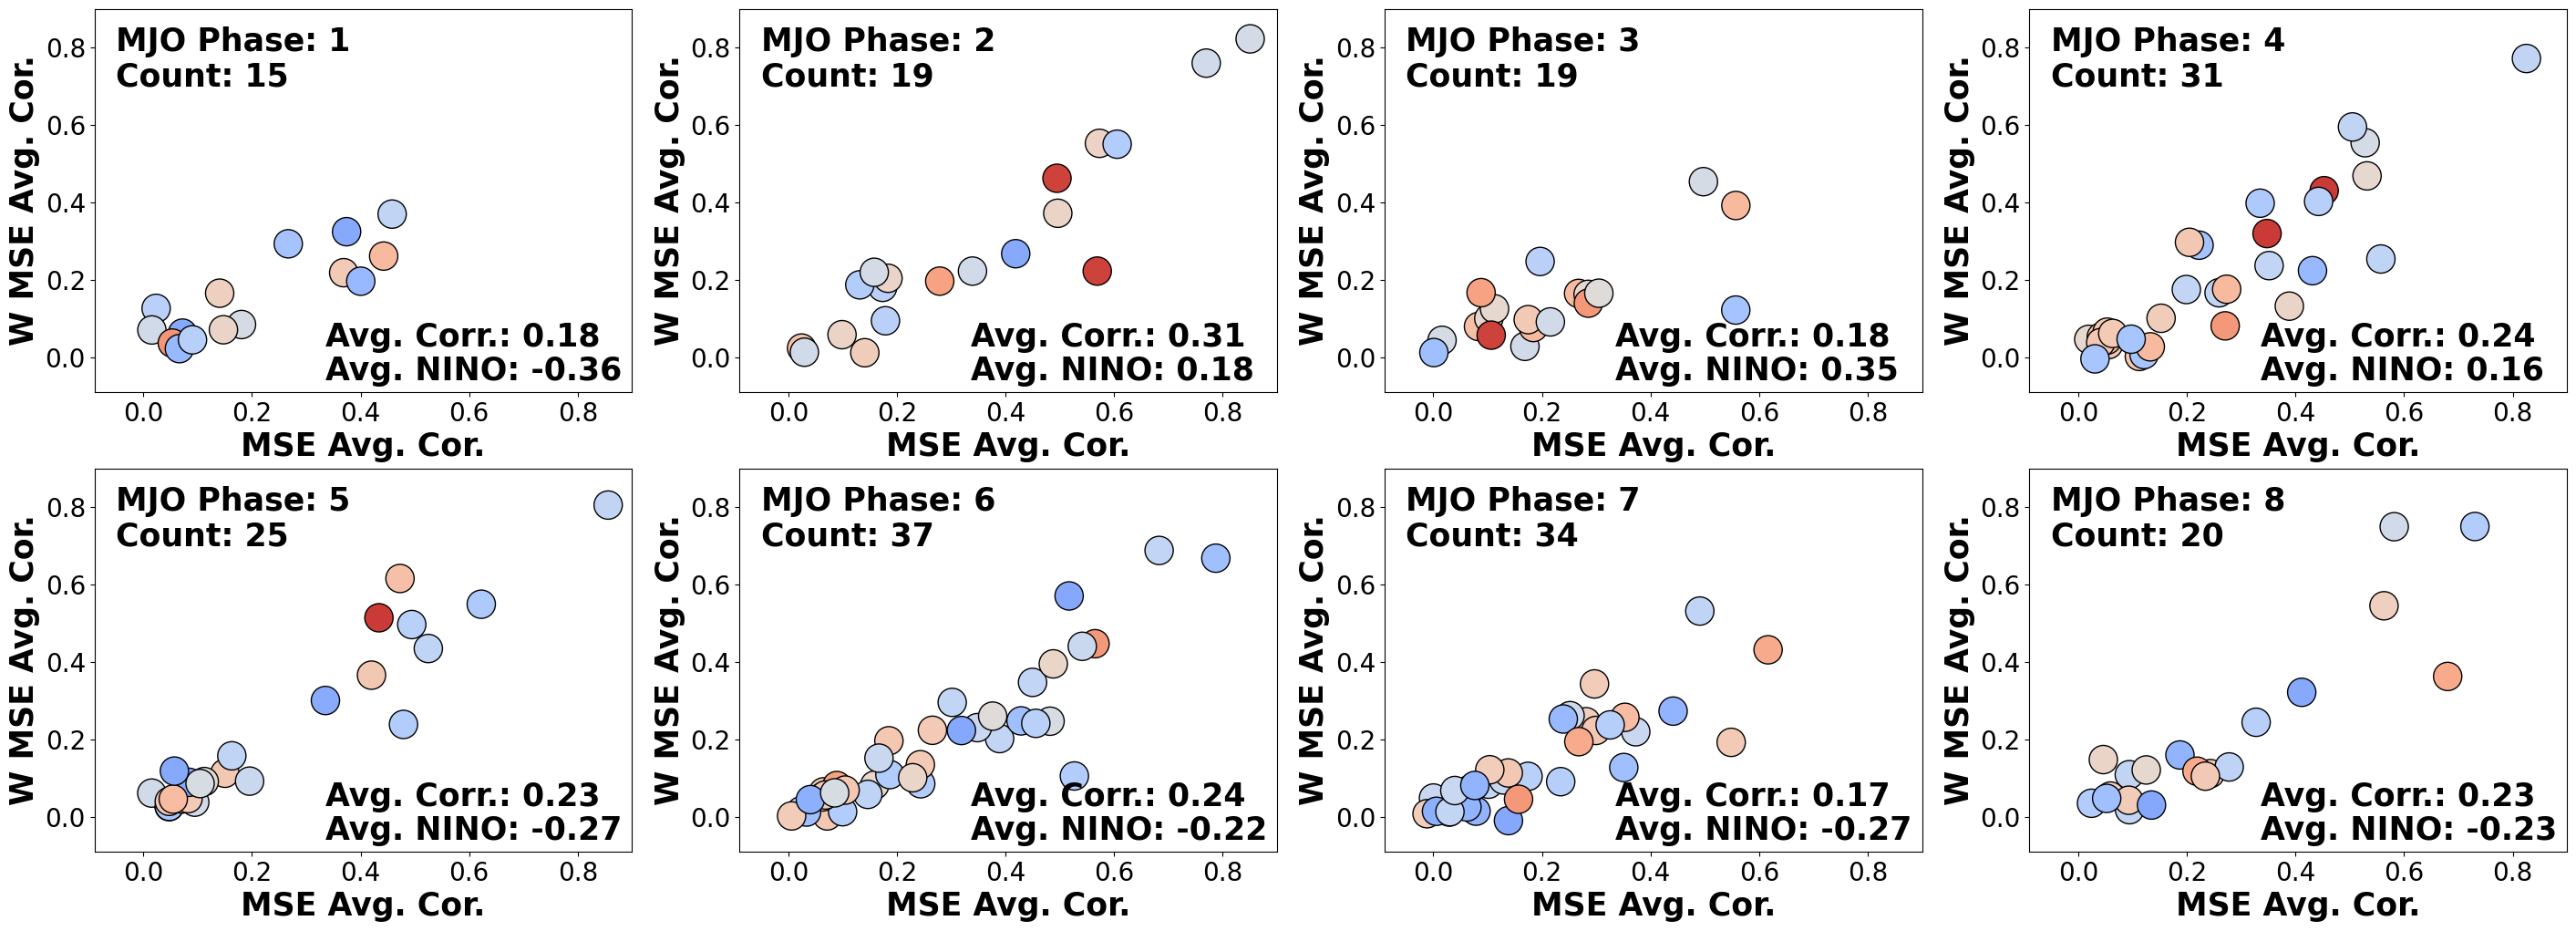

In [12]:
loc = 'ca'
df = locals()[f'y_{loc}_era5_test']

fig = plt.figure(figsize=(35, 12))

for phase in np.arange(1, 9, 1):
    ax = plt.subplot(2,4, phase)
    
    df_cur = df[df['MJO Phase'].values == phase]
    plt.scatter(df_cur['mse_corr'].values, df_cur['weight_mse_corr'].values, 
                c=df_cur['NINO Value'].values, cmap='coolwarm', vmin=-3, vmax = 3,
               edgecolor='k', s=500)
    
    plt.xlim([-0.09, 0.9])
    plt.ylim([-0.09, 0.9])
    
    plt.xlabel(f"MSE Avg. Cor.", fontsize = 25, fontweight='bold')
    plt.ylabel(f"W MSE Avg. Cor.", fontsize = 25, fontweight='bold')
    
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    plt.annotate(f'MJO Phase: {phase}',xy=(0.04,0.89), xycoords='axes fraction', fontsize=25, fontweight='bold')
    plt.annotate(f'Count: {len(df_cur)}',xy=(0.04,0.80), xycoords='axes fraction', fontsize=25, fontweight='bold')
    
    plt.annotate(f'Avg. NINO: {round(np.mean(df_cur['NINO Value'].values), 2)}',xy=(0.43,0.03),
                 xycoords='axes fraction', fontsize=25, fontweight='bold')
    
    plt.annotate(f'Avg. Corr.: {round(np.mean(df_cur[['mse_corr', 'weight_mse_corr']].mean().values),2)}',
                 xy=(0.43,0.12), xycoords='axes fraction', fontsize=25, fontweight='bold')
    
    plt.savefig(f'{loc}_mjo_enso.png', format='png', dpi=500, bbox_inches='tight')

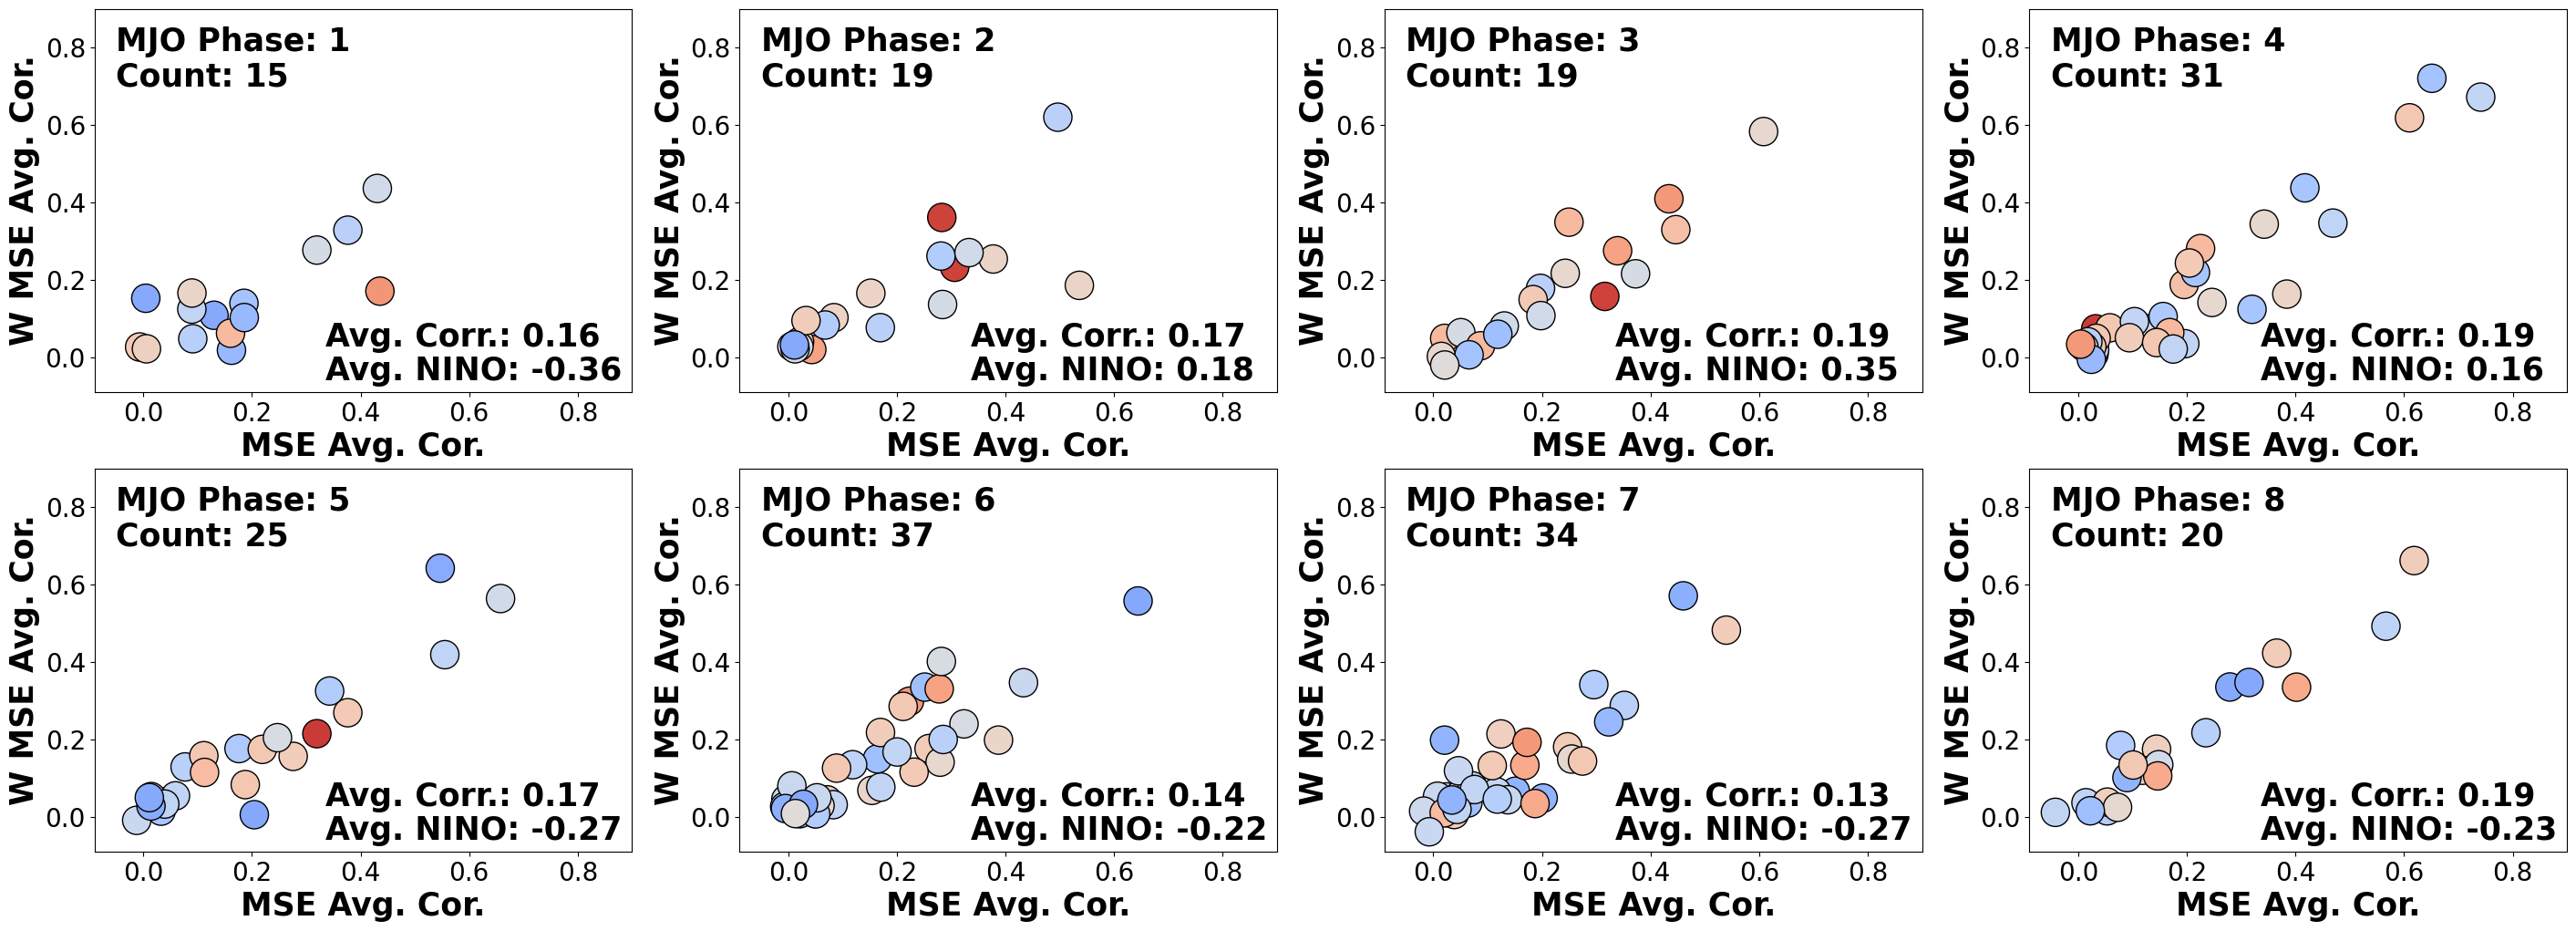

In [13]:
loc = 'gp'
df = locals()[f'y_{loc}_era5_test']

fig = plt.figure(figsize=(35, 12))

for phase in np.arange(1, 9, 1):
    ax = plt.subplot(2,4, phase)
    
    df_cur = df[df['MJO Phase'].values == phase]
    plt.scatter(df_cur['mse_corr'].values, df_cur['weight_mse_corr'].values, 
                c=df_cur['NINO Value'].values, cmap='coolwarm', vmin=-3, vmax = 3,
               edgecolor='k', s=500)
    
    plt.xlim([-0.09, 0.9])
    plt.ylim([-0.09, 0.9])
    
    plt.xlabel(f"MSE Avg. Cor.", fontsize = 25, fontweight='bold')
    plt.ylabel(f"W MSE Avg. Cor.", fontsize = 25, fontweight='bold')
    
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    
    plt.annotate(f'MJO Phase: {phase}',xy=(0.04,0.89), xycoords='axes fraction', fontsize=25, fontweight='bold')
    plt.annotate(f'Count: {len(df_cur)}',xy=(0.04,0.80), xycoords='axes fraction', fontsize=25, fontweight='bold')
    
    plt.annotate(f'Avg. NINO: {round(np.mean(df_cur['NINO Value'].values), 2)}',xy=(0.43,0.03),
                 xycoords='axes fraction', fontsize=25, fontweight='bold')
    
    plt.annotate(f'Avg. Corr.: {round(np.mean(df_cur[['mse_corr', 'weight_mse_corr']].mean().values),2)}',
                 xy=(0.43,0.12), xycoords='axes fraction', fontsize=25, fontweight='bold')
    
    plt.savefig(f'{loc}_mjo_enso.png', format='png', dpi=500, bbox_inches='tight')